In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import jarque_bera
from datetime import datetime, timedelta
import yfinance as yf

# Q1 - Stock selection & market data (main analysis of Tesla)

In [55]:
# Dynamic ticker selection (you have to enter the valid ticker )
# ticker = input("Enter stock ticker (e.g. AAPL, MSFT, TSLA): ").strip().upper()
ticker = "TSLA"
# Validate ticker
info = yf.Ticker(ticker).info
if info.get("regularMarketPrice") is None:
    raise ValueError(f"Ticker '{ticker}' not found. Please check and retry.")

company_name = info.get("longName", ticker)
print(f"\n  Selected: {company_name} ({ticker})")

end_date = datetime(2026, 2, 17)
start_date = end_date - timedelta(days=365)
data = yf.download(ticker, start=start_date, end=end_date)

# Use adjusted close (excludes dividends)
prices = data["Close"].reset_index()
prices.columns = ["Date", "Close"]
prices["Date"] = pd.to_datetime(prices["Date"]).dt.normalize()

# Summary statistics
info = yf.Ticker(ticker).info
company_name = info.get("longName", ticker)

[*********************100%***********************]  1 of 1 completed


  Selected: Tesla, Inc. (TSLA)


In [56]:
print(f"Q1 — Stock Selection: {company_name} ({ticker})")
print("=" * 55)
print(f"  Period:        {prices['Date'].iloc[0].strftime('%Y-%m-%d')} to {prices['Date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"  Observations:  {len(prices)}")
print(f"  Open price:    ${prices['Close'].iloc[0]:.2f}")
print(f"  Close price:   ${prices['Close'].iloc[-1]:.2f}")
print(f"  Min:           ${prices['Close'].min():.2f}")
print(f"  Max:           ${prices['Close'].max():.2f}")
print(f"  Mean:          ${prices['Close'].mean():.2f}")
print(f"  Std dev:       ${prices['Close'].std():.2f}")
print(f"  Return:        {((prices['Close'].iloc[-1] / prices['Close'].iloc[0]) - 1) * 100:+.2f}%")

Q1 — Stock Selection: Tesla, Inc. (TSLA)
  Period:        2025-02-18 to 2026-02-13
  Observations:  250
  Open price:    $354.11
  Close price:   $417.44
  Min:           $221.86
  Max:           $489.88
  Mean:          $361.71
  Std dev:       $72.98
  Return:        +17.88%


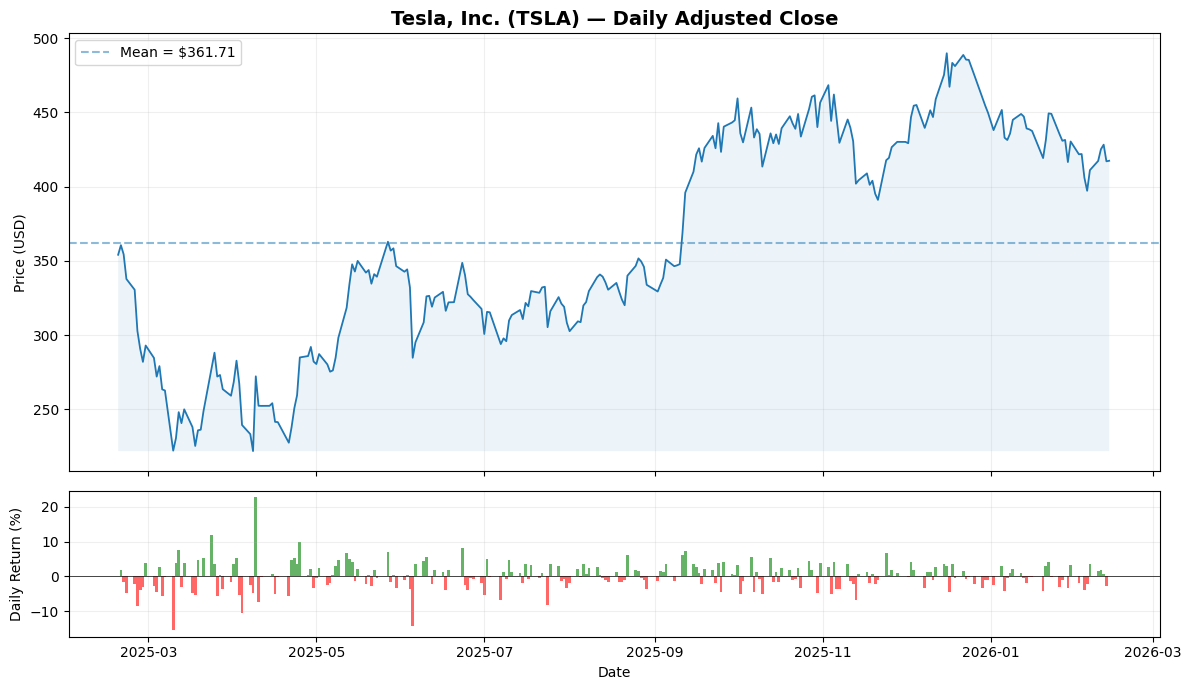

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

# Price chart
axes[0].plot(prices["Date"], prices["Close"], linewidth=1.3)
axes[0].fill_between(prices["Date"], prices["Close"].min(), prices["Close"],  alpha=0.08)
axes[0].axhline(prices["Close"].mean(), linestyle="--", alpha=0.5, label=f"Mean = ${prices['Close'].mean():.2f}")
axes[0].set_title(f"{company_name} ({ticker}) — Daily Adjusted Close", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.2)

# Volume / daily return chart
daily_returns = prices["Close"].pct_change().dropna()
colors = ["green" if r >= 0 else "red" for r in daily_returns]
axes[1].bar(prices["Date"].iloc[1:], daily_returns * 100, color=colors, alpha=0.6, width=1)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Daily Return (%)")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

# Q2 - Parameter estimation

In [58]:
# 2a) Risk-free rate - last available 10Y Treasury yield

# Source: https://fred.stlouisfed.org/series/DGS10
r_df = pd.read_csv("/Users/eduardo/Desktop/Python_Coding/Quant Finance/RiskManagement/Project/DGS1.csv")
#r_df = pd.read_csv("/content/DGS1.csv")

r_df = r_df.rename(columns={"observation_date": "Date"})
r_df["Date"] = pd.to_datetime(r_df["Date"]).dt.normalize()
r_df["DGS1"] = pd.to_numeric(r_df["DGS1"], errors="coerce")

df = pd.merge(prices, r_df, on="Date", how="inner").dropna()

r = df["DGS1"].iloc[-1] / 100

In [59]:
# 2b) Projection period = 1 year
T = 1.0

# 2c) Annualized volatility
daily_log_returns = np.log(df["Close"]).diff().dropna()
mu_daily = daily_log_returns.mean()
mu_annual = mu_daily * 252

sigma_daily = daily_log_returns.std(ddof=1)
sigma_annual = sigma_daily * np.sqrt(252)

# Spot price and strike
S = df["Close"].iloc[-1]
K = df["Close"].mean()

In [60]:
print("Q2 -- Parameters")
print("=" * 50)
print(f"  Risk-free rate (r):      {r:.4f} ({r*100:.2f}%)")
print(f"  Source:                  FRED 1Y Treasury (DGS1)")
print(f"  Projection period (T):   {T} year")
print(f"  Current price (S):       ${S:.2f}")
print(f"  Strike price (K = mean): ${K:.2f}")
print(f"  Daily mean return (mu):  {mu_daily:.6f}")
print(f"  Annualized return (mu):  {mu_annual:.4f} ({mu_annual*100:.2f}%)")
print(f"  Daily volatility:        {sigma_daily:.6f}")
print(f"  Annualized vol (sigma):  {sigma_annual:.4f} ({sigma_annual*100:.2f}%)")

Q2 -- Parameters
  Risk-free rate (r):      0.0342 (3.42%)
  Source:                  FRED 1Y Treasury (DGS1)
  Projection period (T):   1.0 year
  Current price (S):       $417.44
  Strike price (K = mean): $361.10
  Daily mean return (mu):  0.000666
  Annualized return (mu):  0.1679 (16.79%)
  Daily volatility:        0.038906
  Annualized vol (sigma):  0.6176 (61.76%)


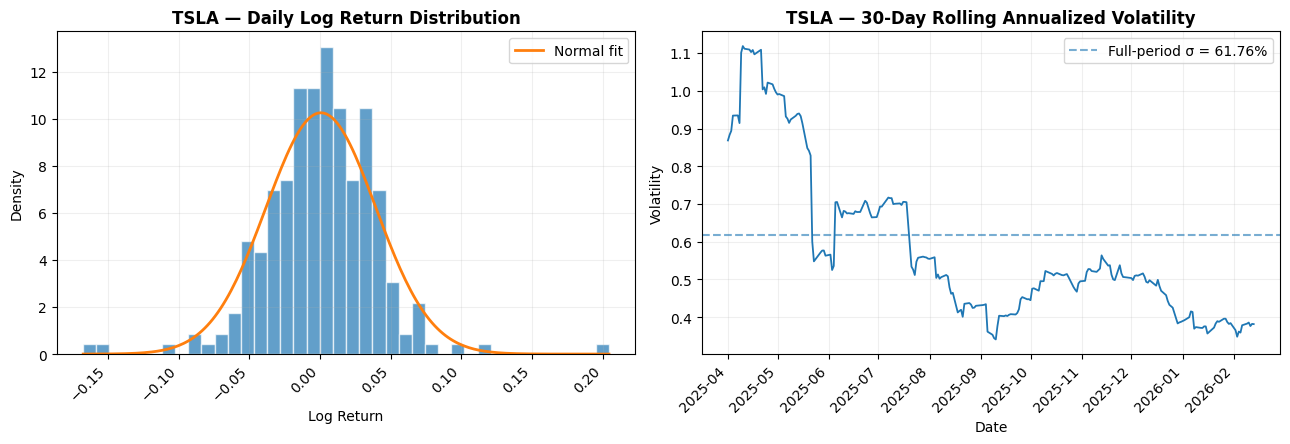

In [61]:
# Chart: volatility analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Return distribution
axes[0].hist(daily_log_returns, bins=40, density=True, alpha=0.7, edgecolor="white")
x = np.linspace(daily_log_returns.min(), daily_log_returns.max(), 200)
axes[0].plot(x, norm.pdf(x, mu_daily, sigma_daily), linewidth=2, label="Normal fit")
axes[0].set_title(f"{ticker} — Daily Log Return Distribution", fontweight="bold")
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Rolling volatility
rolling_vol = daily_log_returns.rolling(30).std() * np.sqrt(252)
axes[1].plot(df["Date"].iloc[1:], rolling_vol.values, linewidth=1.3)
axes[1].axhline(sigma_annual, linestyle="--", alpha=0.6,
                label=f"Full-period σ = {sigma_annual:.2%}")
axes[1].set_title(f"{ticker} — 30-Day Rolling Annualized Volatility", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volatility")
axes[1].legend()
axes[1].grid(True, alpha=0.2)


fig.tight_layout()
fig.autofmt_xdate(rotation=45)
plt.show()

###Divers

In [62]:
returns = daily_log_returns

print(f"{'Skewness:':.<40} {returns.skew():.4f}")
print(f"{'Kurtosis:':.<40} {returns.kurtosis():.4f}")
print(f"{'Jarque-Bera stat:':.<40} {jarque_bera(returns)[0]:.2f}")
print(f"{'Jarque-Bera p-value:':.<40} {jarque_bera(returns)[1]:.4e}")
print(f"{'Normality (5% level):':.<40} {'Rejected' if jarque_bera(returns)[1] < 0.05 else 'Not rejected'}")
print(f"\nNormality is {'rejected' if jarque_bera(returns)[1] < 0.05 else 'not rejected'} at the 5% level.")


Skewness:............................... -0.0070
Kurtosis:............................... 4.5220
Jarque-Bera stat:....................... 199.86
Jarque-Bera p-value:.................... 3.9843e-44
Normality (5% level):................... Rejected

Normality is rejected at the 5% level.


# Q3 - Black-Scholes

## (a) - Black–Scholes Model

The **Black–Scholes–Merton (1973)** model prices European options using a closed-form formula.

### Option Pricing Formulas

Call option price:

$$
C = S\,N(d_1) - K e^{-rT} N(d_2)
$$

Put option price:

$$
P = K e^{-rT} N(-d_2) - S N(-d_1)
$$

### Definitions of \( $d_1$ \) and \( $d_2$ \)

$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}
$$


$$
d_2 = d_1 - \sigma\sqrt{T}
$$

### Model Assumptions

1. The stock price follows **Geometric Brownian Motion** with constant drift and volatility.  
2. **No dividends** are paid during the life of the option.  
3. **No transaction costs or taxes**.  
4. The **risk-free interest rate \(r\)** is constant and known.  
5. The **volatility \( $\sigma$ \)** of the underlying asset is constant and known.  
6. The option is **European-style**, meaning it can only be exercised at expiration.  
7. **Short selling is allowed** without restrictions.  
8. **Continuous trading** in the market is possible.  
9. Asset returns are **log-normally distributed**.

## (b) - Defining Call option pricing

In [63]:
N = norm.cdf

def BS_CALL(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * N(d1) - K * np.exp(-r * T) * N(d2)

def BS_PUT_PARITY(call_price, S, K, T, r):
    return call_price - S + K * np.exp(-r * T)

#===== Function call =====
ln_SK = np.log(S / K)
r_plus_half_sig2 = r + sigma_annual**2 / 2
sig_sqrtT = sigma_annual * np.sqrt(T)
discount = np.exp(-r * T)
PV_K = K * discount

d1 = (ln_SK + r_plus_half_sig2 * T) / sig_sqrtT
d2 = d1 - sig_sqrtT

Nd1 = N(d1)
Nd2 = N(d2)
Nmd1 = N(-d1)
Nmd2 = N(-d2)

call_price = S * Nd1 - PV_K * Nd2
put_price = BS_PUT_PARITY(call_price, S, K, T, r)
put_direct = PV_K * Nmd2 - S * Nmd1

In [64]:
# Helper: BS Greeks
def bs_delta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return N(d1)

def bs_gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

In [65]:
print(f"Q3b — Call Option Pricing: {company_name} ({ticker})")
print("=" * 65)

print(f"\n  INPUT PARAMETERS")
print(f"  {'Spot price (S):':.<40} ${S:.2f}")
print(f"  {'Strike price (K = mean):':.<40} ${K:.2f}")
print(f"  {'Time to maturity (T):':.<40} {T:.2f} years")
print(f"  {'Risk-free rate (r):':.<40} {r:.4f} ({r*100:.2f}%)")
print(f"  {'Volatility (σ):':.<40} {sigma_annual:.4f} ({sigma_annual*100:.2f}%)")
print(f"  {'Moneyness (S/K):':.<40} {S/K:.4f} ({'ITM' if S > K else 'OTM' if S < K else 'ATM'})")

print(f"\n  INTERMEDIATE CALCULATIONS")
print(f"  {'ln(S/K):':.<40} {ln_SK:.6f}")
print(f"  {'r + σ²/2:':.<40} {r_plus_half_sig2:.6f}")
print(f"  {'σ × √T:':.<40} {sig_sqrtT:.6f}")
print(f"  {'e^(-rT):':.<40} {discount:.6f}")
print(f"  {'PV(K) = K × e^(-rT):':.<40} ${PV_K:.2f}")

print(f"\n  d1 = [ln(S/K) + (r + σ²/2)×T] / (σ×√T)")
print(f"     = [{ln_SK:.6f} + {r_plus_half_sig2:.6f} × {T}] / {sig_sqrtT:.6f}")
print(f"     = {d1:.6f}")
print(f"  d2 = d1 − σ×√T")
print(f"     = {d1:.6f} − {sig_sqrtT:.6f}")
print(f"     = {d2:.6f}")

print(f"\n  NORMAL CDF VALUES")
print(f"  {'N(d1):':.<40} {Nd1:.6f}")
print(f"  {'N(d2):':.<40} {Nd2:.6f}")
print(f"  {'N(-d1):':.<40} {Nmd1:.6f}")
print(f"  {'N(-d2):':.<40} {Nmd2:.6f}")

print(f"\n  CALL PRICE")
print(f"  C = S × N(d1) − K × e^(-rT) × N(d2)")
print(f"    = {S:.2f} × {Nd1:.6f} − {PV_K:.2f} × {Nd2:.6f}")
print(f"    = {S * Nd1:.2f} − {PV_K * Nd2:.2f}")
print(f"  |---------------------------------|")
print(f"  |  Call Price (C) = ${call_price:>10.2f}   |")
print(f"  |---------------------------------|")


Q3b — Call Option Pricing: Tesla, Inc. (TSLA)

  INPUT PARAMETERS
  Spot price (S):......................... $417.44
  Strike price (K = mean):................ $361.10
  Time to maturity (T):................... 1.00 years
  Risk-free rate (r):..................... 0.0342 (3.42%)
  Volatility (σ):......................... 0.6176 (61.76%)
  Moneyness (S/K):........................ 1.1560 (ITM)

  INTERMEDIATE CALCULATIONS
  ln(S/K):................................ 0.144987
  r + σ²/2:............................... 0.224921
  σ × √T:................................. 0.617611
  e^(-rT):................................ 0.966378
  PV(K) = K × e^(-rT):.................... $348.96

  d1 = [ln(S/K) + (r + σ²/2)×T] / (σ×√T)
     = [0.144987 + 0.224921 × 1.0] / 0.617611
     = 0.598935
  d2 = d1 − σ×√T
     = 0.598935 − 0.617611
     = -0.018675

  NORMAL CDF VALUES
  N(d1):.................................. 0.725392
  N(d2):.................................. 0.492550
  N(-d1):..................

## (c) - Put Option via Put–Call Parity

Using **Put–Call Parity**, the relationship between European call and put prices is:

$$
C - P = S - K e^{-rT}
$$

Rearranging to solve for the **put price**:

$$
P = C - S + K e^{-rT}
$$

In [66]:
# Q3c - Put option via Put-Call Parity + Payoff & PnL

put_breakeven = K - put_price
call_breakeven = K + call_price

In [67]:
print(f"Q3c — Put Option via Put-Call Parity")
print(f"{'=' * 65}")

print(f"\n  PUT-CALL PARITY")
print(f"  C − P = S − K×e^(-rT)")
print(f"  P = C − S + K×e^(-rT)")
print(f"    = {call_price:.2f} − {S:.2f} + {PV_K:.2f}")
print(f"\n  |---------------------------------|")
print(f"  |  Put Price (P)  = ${put_price:>10.2f}   |")
print(f"  |---------------------------------|")

print(f"\n  VERIFICATION (direct BS put formula)")
print(f"  P = K×e^(-rT)×N(-d2) − S×N(-d1)")
print(f"    = {PV_K:.2f} × {Nmd2:.6f} − {S:.2f} × {Nmd1:.6f}")
print(f"    = ${put_direct:.2f}")
print(f"  Parity holds: {np.isclose(put_price, put_direct)} (diff = ${abs(put_price - put_direct):.2e})")

Q3c — Put Option via Put-Call Parity

  PUT-CALL PARITY
  C − P = S − K×e^(-rT)
  P = C − S + K×e^(-rT)
    = 130.93 − 417.44 + 348.96

  |---------------------------------|
  |  Put Price (P)  = $     62.45   |
  |---------------------------------|

  VERIFICATION (direct BS put formula)
  P = K×e^(-rT)×N(-d2) − S×N(-d1)
    = 348.96 × 0.507450 − 417.44 × 0.274608
    = $62.45
  Parity holds: True (diff = $2.84e-14)


In [68]:
print(f"\n  PAYOFF & PnL ANALYSIS")
print(f"  {'':>30} {'Call':>12} {'Put':>12}")
print(f"  {'-'*30} {'-'*12} {'-'*12}")
print(f"  {'Premium:':>30} ${call_price:>11.2f} ${put_price:>11.2f}")
print(f"  {'Max profit:':>30} {'Unlimited':>12} ${K - put_price:>11.2f}")
print(f"  {'Max loss:':>30} ${-call_price:>11.2f} ${-put_price:>11.2f}")
print(f"  {'Break-even:':>30} ${call_breakeven:>11.2f} ${put_breakeven:>11.2f}")
print(f"  {'Payoff at S_T = S:':>30} ${max(S - K, 0):>11.2f} ${max(K - S, 0):>11.2f}")
print(f"  {'PnL at S_T = S:':>30} ${max(S - K, 0) - call_price:>11.2f} ${max(K - S, 0) - put_price:>11.2f}")


  PAYOFF & PnL ANALYSIS
                                         Call          Put
  ------------------------------ ------------ ------------
                        Premium: $     130.93 $      62.45
                     Max profit:    Unlimited $     298.65
                       Max loss: $    -130.93 $     -62.45
                     Break-even: $     492.03 $     298.65
              Payoff at S_T = S: $      56.34 $       0.00
                 PnL at S_T = S: $     -74.59 $     -62.45


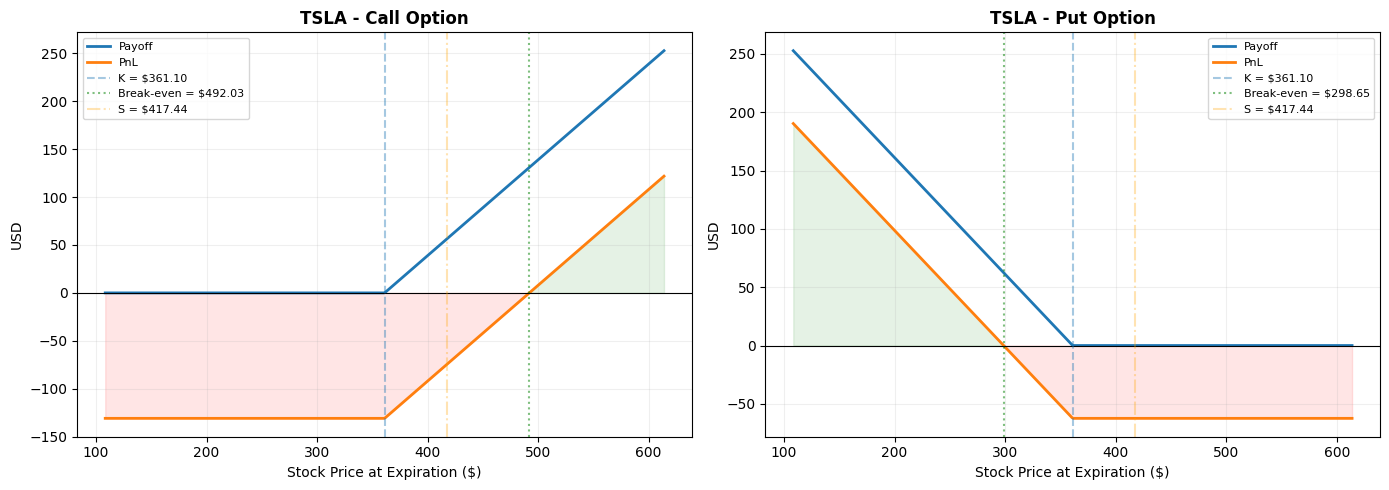

In [69]:
ST_range = np.linspace(K * 0.3, K * 1.7, 500)
call_payoff = np.maximum(ST_range - K, 0)
call_pnl = call_payoff - call_price
put_payoff = np.maximum(K - ST_range, 0)
put_pnl = put_payoff - put_price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, payoff, pnl, title, be in [
    (axes[0], call_payoff, call_pnl, "Call Option", call_breakeven),
    (axes[1], put_payoff, put_pnl, "Put Option", put_breakeven)
]:
    ax.plot(ST_range, payoff, linewidth=2, label="Payoff")
    ax.plot(ST_range, pnl, linewidth=2, label="PnL")
    ax.fill_between(ST_range, pnl, 0, where=(pnl > 0), alpha=0.1, color="green")
    ax.fill_between(ST_range, pnl, 0, where=(pnl < 0), alpha=0.1, color="red")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(K, linestyle="--", alpha=0.4, label=f"K = ${K:.2f}")
    ax.axvline(be, linestyle=":", alpha=0.5, color="green", label=f"Break-even = ${be:.2f}")
    ax.axvline(S, linestyle="-.", alpha=0.3, color="orange", label=f"S = ${S:.2f}")
    ax.set_title(f"{ticker} - {title}", fontweight="bold")
    ax.set_xlabel("Stock Price at Expiration ($)")
    ax.set_ylabel("USD")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

###Divers

In [70]:
# Risk-neutral vs real-world probabilities
prob_ITM_rn = N(d2)           # Risk-neutral P(S_T > K)
d2_real = (np.log(S / K) + (mu_annual - sigma_annual**2 / 2) * T) / (sigma_annual * np.sqrt(T))
prob_ITM_real = N(d2_real)    # Real-world P(S_T > K)

print(f"\n  PROBABILITY ANALYSIS")
print(f"  {'':>35} {'Call':>12} {'Put':>12}")
print(f"  {'-'*35} {'-'*12} {'-'*12}")
print(f"  {'P(ITM) risk-neutral:':>35} {N(d2):>11.2%} {N(-d2):>11.2%}")
print(f"  {'P(ITM) real-world:':>35} {N(d2_real):>11.2%} {N(-d2_real):>11.2%}")
print(f"  {'Intrinsic value:':>35} ${max(S-K,0):>11.2f} ${max(K-S,0):>11.2f}")
print(f"  {'Time value:':>35} ${call_price - max(S-K,0):>11.2f} ${put_price - max(K-S,0):>11.2f}")

# Sensitivity table (mini Greeks preview)
bumps = [("S +1%", BS_CALL(S*1.01, K, T, r, sigma_annual) - call_price, BS_PUT_PARITY(BS_CALL(S*1.01, K, T, r, sigma_annual), S*1.01, K, T, r) - put_price),
         ("S −1%", BS_CALL(S*0.99, K, T, r, sigma_annual) - call_price, BS_PUT_PARITY(BS_CALL(S*0.99, K, T, r, sigma_annual), S*0.99, K, T, r) - put_price),
         ("σ +1%", BS_CALL(S, K, T, r, sigma_annual+0.01) - call_price, BS_PUT_PARITY(BS_CALL(S, K, T, r, sigma_annual+0.01), S, K, T, r) - put_price),
         ("r +0.25%", BS_CALL(S, K, T, r+0.0025, sigma_annual) - call_price, BS_PUT_PARITY(BS_CALL(S, K, T, r+0.0025, sigma_annual), S, K, T, r+0.0025) - put_price),
         ("T −1 day", BS_CALL(S, K, T-1/252, r, sigma_annual) - call_price, BS_PUT_PARITY(BS_CALL(S, K, T-1/252, r, sigma_annual), S, K, T-1/252, r) - put_price)]

print(f"\n  SENSITIVITY ANALYSIS")
print(f"  {'Scenario':>15}  {'ΔCall':>10}  {'ΔPut':>10}")
print(f"  {'-'*15}  {'-'*10}  {'-'*10}")
for label, dc, dp in bumps:
    print(f"  {label:>15}  ${dc:>+9.2f}  ${dp:>+9.2f}")


  PROBABILITY ANALYSIS
                                              Call          Put
  ----------------------------------- ------------ ------------
                 P(ITM) risk-neutral:      49.26%      50.74%
                   P(ITM) real-world:      57.84%      42.16%
                     Intrinsic value: $      56.34 $       0.00
                          Time value: $      74.59 $      62.45

  SENSITIVITY ANALYSIS
         Scenario       ΔCall        ΔPut
  ---------------  ----------  ----------
            S +1%  $    +3.04  $    -1.14
            S −1%  $    -3.02  $    +1.16
            σ +1%  $    +1.39  $    +1.39
         r +0.25%  $    +0.43  $    -0.44
         T −1 day  $    -0.19  $    -0.15


# Q4 - Greeks (sensitivities)
In option pricing, the **Greeks** are partial derivatives of the option value with respect to model inputs.
They quantify how the option price reacts to changes in the underlying factors such as price, time, volatility, and rates.

The key Greeks of Black-Scholes for European Options are:

- **Delta** expresses the irectional exposure to the underlying price
:  
  $$
  \Delta = \frac{\partial C}{\partial S}
  $$  

- **Gamma** captures the curvature of the option value (how Delta changes when $S$ moves):  
  $$
  \Gamma = \frac{\partial^2 C}{\partial S^2}
  $$  

- **Theta** reflects time decay:  
  $$
  \Theta = \frac{\partial C}{\partial t}
  $$  
  

- **Vega** expresses sensitivity to volatility:  
  $$
  \nu = \frac{\partial C}{\partial \sigma}
  $$  
  .

- **Rho**  reflects the sensitivity to the risk-free interest rate:  
  $$
  \rho = \frac{\partial C}{\partial r}
  $$  

Below, we compute the Greeks for the call option priced in **Q3b** (using the same $S, K, T, r, \sigma$).


$$\Theta_{put}=-\frac{S_0 N'(d_1)\sigma}{2\sqrt{T}}+rKe^{-rT}N(-d_2)$$

In [71]:
# Q4 — Greeks for the Q3b call option
def bs_d1_d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return S * N(d1) - K * np.exp(-r * T) * N(d2)


In [72]:
# Q4 — Greeks for the Q3b Call Option

def bs_greeks_call(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    npdf_d1 = norm.pdf(d1)

    delta = N(d1)
    gamma = npdf_d1 / (S * sigma * np.sqrt(T))
    theta_annual = -S * npdf_d1 * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * N(d2)
    theta_daily = theta_annual / 252
    vega = S * npdf_d1 * np.sqrt(T)   # per 1.0 (100%) vol change
    rho = K * T * np.exp(-r * T) * N(d2)  # per 1.0 (100%) rate change

    return delta, gamma, theta_daily, vega, rho

delta, gamma, theta_daily, vega, rho = bs_greeks_call(S, K, T, r, sigma_annual)

sigma_bump = 0.025  # +2.5%
r_bump = 0.014      # +1.4%

# Dollar impacts
vega_impact = BS_CALL(S, K, T, r, sigma_annual + sigma_bump) - call_price
rho_impact = BS_CALL(S, K, T, r + r_bump, sigma_annual) - call_price

# Approximation via Greek × bump (first-order)
vega_approx = vega * sigma_bump
rho_approx = rho * r_bump

In [73]:
print(f"Q4 — Greeks: {company_name} ({ticker}) Call Option")
print("=" * 65)
print(f"Using parameters from Q3b:")
print(f"S=${S:.2f}, K=${K:.2f}, T={T:.1f}y, r={r:.4f}, σ={sigma_annual:.4f}")

print(f"\nDELTA - Sensitivity to stock price")
print(f"{'Formula:':.<40} N(d1)")
print(f"{'Value:':.<40} {delta:.6f}")
print(f"A $1 increase in {ticker} increases the call value by ${delta:.2f}. Delta also approximates the probability of expiring ITM ({delta:.1%} risk-neutral).")

print(f"\nGAMMA - Rate of change of Delta")
print(f"{'Formula:':.<40} N′(d1) / (S × σ × √T)")
print(f"{'Value:':.<40} {gamma:.6f}")
print(f"A $1 move changes delta by {gamma:.4f}. Gamma is highest near ATM and measures convexity risk.")

print(f"\nTHETA - Time decay (daily)")
print(f"{'Formula:':.<40} [−S×N′(d1)×σ/(2√T) − rKe^(−rT)N(d2)] / 252")
print(f"{'Value:':.<40} {theta_daily:.6f} $/day")
print(f"The call loses ${abs(theta_daily):.2f} per calendar day, all else equal. Over one week: ${abs(theta_daily * 5):.2f}.")

print(f"\nVEGA - Sensitivity to volatility (+{sigma_bump*100:.1f}%)")
print(f"{'Formula:':.<40} S × N′(d1) × √T")
print(f"{'Analytical vega (per 100%):':.<40} {vega:.4f}")
print(f"{'Vega × {:.1f}% bump (approx):'.format(sigma_bump*100):.<40} ${vega_approx:.2f}")
print(f"{'Actual repricing (exact):':.<40} ${vega_impact:.2f}")
print(f"{'Approximation error:':.<40} ${abs(vega_impact - vega_approx):.2f}")
print(f"A {sigma_bump*100:.1f}% increase in volatility raises the call price by ${vega_impact:.2f} (from ${call_price:.2f} to ${call_price + vega_impact:.2f}).")

print(f"\nRHO - Sensitivity to risk-free rate (+{r_bump*100:.1f}%)")
print(f"{'Formula:':.<40} K × T × e^(−rT) × N(d2)")
print(f"{'Analytical rho (per 100%):':.<40} {rho:.4f}")
print(f"{'Rho × {:.1f}% bump (approx):'.format(r_bump*100):.<40} ${rho_approx:.2f}")
print(f"{'Actual repricing (exact):':.<40} ${rho_impact:.2f}")
print(f"{'Approximation error:':.<40} ${abs(rho_impact - rho_approx):.2f}")
print(f"A {r_bump*100:.1f}% increase in the risk-free rate raises the call price by ${rho_impact:.2f} (from ${call_price:.2f} to ${call_price + rho_impact:.2f}).")

# Summary table
print(f"\n{'-'*65}")
print(f"{'SUMMARY':^65}")
print(f"{'-'*65}")
print(f"{'Greek':>10} {'Value':>12} {'Interpretation':>40}")
print(f"{'_'*10} {'_'*12} {'_'*40}")
print(f"{'Delta':>10} {delta:>12.4f} {'$1 price move => ${:.2f} call change'.format(delta):>40}")
print(f"{'Gamma':>10} {gamma:>12.6f} {'$1 move => Delta changes by {:.4f}'.format(gamma):>40}")
print(f"{'Theta':>10} {theta_daily:>12.4f} {'Loses ${:.2f}/day to time decay'.format(abs(theta_daily)):>40}")
print(f"{'Vega':>10} {vega_impact:>+12.2f} {'+{:.1f}% vol => +${:.2f} call change'.format(sigma_bump*100, vega_impact):>40}")
print(f"{'Rho':>10} {rho_impact:>+12.2f} {'+{:.1f}% rate => +${:.2f} call change'.format(r_bump*100, rho_impact):>40}")

Q4 — Greeks: Tesla, Inc. (TSLA) Call Option
Using parameters from Q3b:
S=$417.44, K=$361.10, T=1.0y, r=0.0342, σ=0.6176

DELTA - Sensitivity to stock price
Formula:................................ N(d1)
Value:.................................. 0.725392
A $1 increase in TSLA increases the call value by $0.73. Delta also approximates the probability of expiring ITM (72.5% risk-neutral).

GAMMA - Rate of change of Delta
Formula:................................ N′(d1) / (S × σ × √T)
Value:.................................. 0.001293
A $1 move changes delta by 0.0013. Gamma is highest near ATM and measures convexity risk.

THETA - Time decay (daily)
Formula:................................ [−S×N′(d1)×σ/(2√T) − rKe^(−rT)N(d2)] / 252
Value:.................................. -0.193893 $/day
The call loses $0.19 per calendar day, all else equal. Over one week: $0.97.

VEGA - Sensitivity to volatility (+2.5%)
Formula:................................ S × N′(d1) × √T
Analytical vega (per 100%):....

**Interpretation (for your specific numbers):**

- A **Delta** close to 1 means the call behaves like the stock; close to 0 means it behaves like a far OTM call.
- **Gamma** is largest for near-the-money options and short maturities. Large Gamma means Delta changes quickly as \(S\) moves.
- **Theta** is typically negative for long options: as time passes (all else equal), time value erodes.
- **Vega** is usually positive for vanilla calls: higher \(\sigma\) increases option value (more dispersion in \(S_T\)).
- **Rho** for calls is usually positive: higher rates increase call value via discounting of the strike.


###Divers

In [74]:
# Put Greeks via put-call parity relationships
delta_put = delta - 1
gamma_put = gamma
theta_put_annual = (-S * norm.pdf(d1) * sigma_annual / (2 * np.sqrt(T))
                    + r * K * np.exp(-r * T) * N(-d2))
theta_put_daily = theta_put_annual / 252
vega_put = vega
rho_put = -K * T * np.exp(-r * T) * N(-d2)

vega_impact_put = BS_PUT_PARITY(BS_CALL(S, K, T, r, sigma_annual + sigma_bump), S, K, T, r) - put_price
rho_impact_put = BS_PUT_PARITY(BS_CALL(S, K, T, r + r_bump, sigma_annual), S, K, T, r + r_bump) - put_price

print(f"CALL vs PUT GREEKS COMPARISON")
print(f"{'Greek':>10}  {'Call':>12}  {'Put':>12}  {'Relationship':>25}")
print(f"{'_'*10}  {'_'*12}  {'_'*12}  {'_'*25}")
print(f"{'Delta':>10}  {delta:>+12.4f}  {delta_put:>+12.4f}  {'Δ_put = Δ_call − 1':>25}")
print(f"{'Gamma':>10}  {gamma:>12.6f}  {gamma_put:>12.6f}  {'Γ_put = Γ_call':>25}")
print(f"{'Theta':>10}  {theta_daily:>12.4f}  {theta_put_daily:>12.4f}  {'Different formulas':>25}")
print(f"{'Vega Δ$':>10}  ${vega_impact:>+11.2f}  ${vega_impact_put:>+11.2f}  {'ν_put = ν_call':>25}")
print(f"{'Rho Δ$':>10}  ${rho_impact:>+11.2f}  ${rho_impact_put:>+11.2f}  {'Opposite signs':>25}")

CALL vs PUT GREEKS COMPARISON
     Greek          Call           Put               Relationship
__________  ____________  ____________  _________________________
     Delta       +0.7254       -0.2746         Δ_put = Δ_call − 1
     Gamma      0.001293      0.001293             Γ_put = Γ_call
     Theta       -0.1939       -0.1465         Different formulas
   Vega Δ$  $      +3.48  $      +3.48             ν_put = ν_call
    Rho Δ$  $      +2.41  $      -2.44             Opposite signs


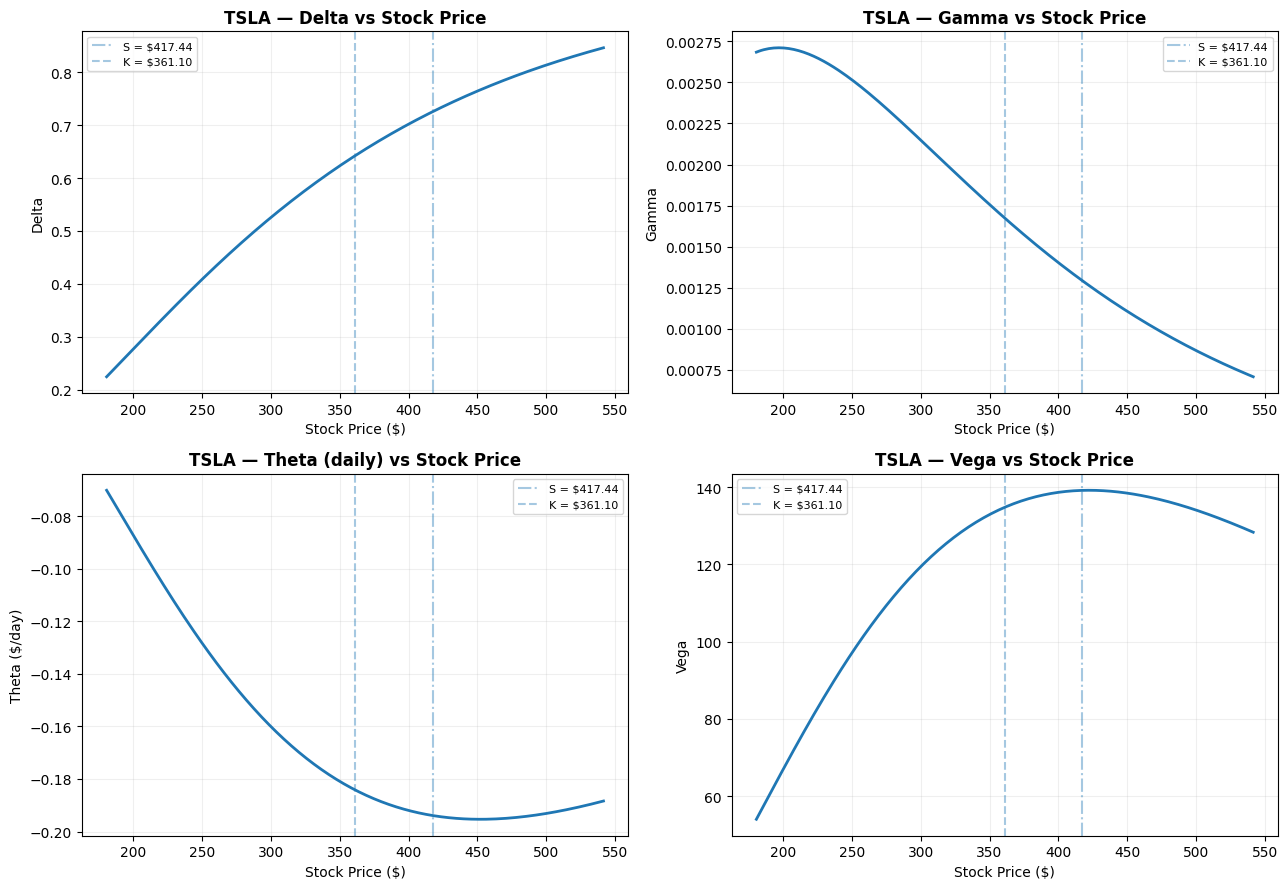

In [75]:
# Greeks as a function of stock price
S_range = np.linspace(K * 0.5, K * 1.5, 200)

greeks_over_S = [bs_greeks_call(s, K, T, r, sigma_annual) for s in S_range]
deltas = [g[0] for g in greeks_over_S]
gammas = [g[1] for g in greeks_over_S]
thetas = [g[2] for g in greeks_over_S]
vegas  = [bs_vega(s, K, T, r, sigma_annual) for s in S_range]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, values, title, ylabel in [
    (axes[0,0], deltas, "Delta vs Stock Price", "Delta"),
    (axes[0,1], gammas, "Gamma vs Stock Price", "Gamma"),
    (axes[1,0], thetas, "Theta (daily) vs Stock Price", "Theta ($/day)"),
    (axes[1,1], vegas,  "Vega vs Stock Price", "Vega"),
]:
    ax.plot(S_range, values, linewidth=2)
    ax.axvline(S, linestyle="-.", alpha=0.4, label=f"S = ${S:.2f}")
    ax.axvline(K, linestyle="--", alpha=0.4, label=f"K = ${K:.2f}")
    ax.set_title(f"{ticker} — {title}", fontweight="bold")
    ax.set_xlabel("Stock Price ($)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

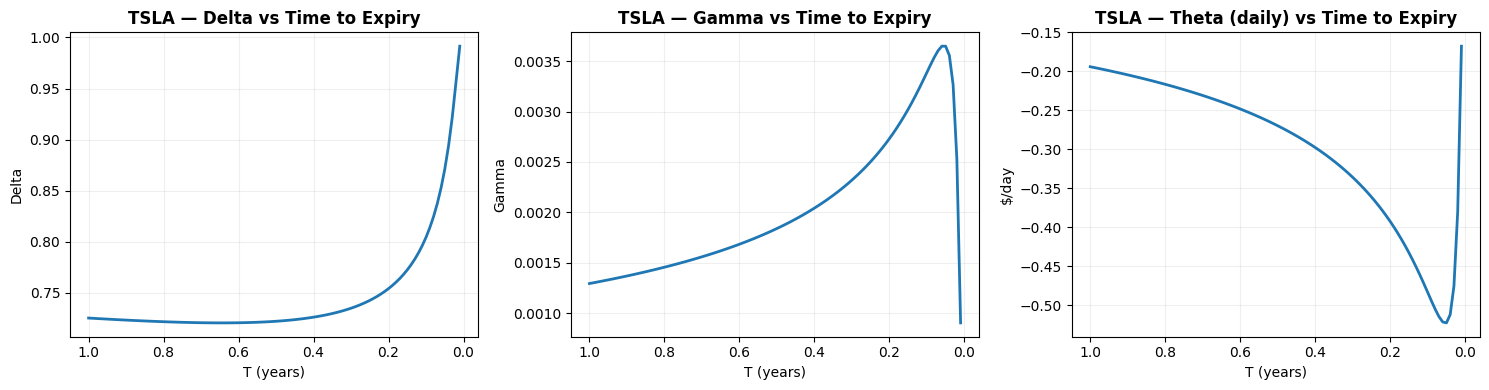

As T -> 0:
Delta -> 1.0 (deep ITM)
Gamma spikes near expiry for near-ATM options
Theta accelerates - time decay is fastest in the last weeks


In [76]:
# Greeks as T decreases (time to expiration)
T_range = np.linspace(T, 0.01, 100)

greeks_over_T = [bs_greeks_call(S, K, t, r, sigma_annual) for t in T_range]
deltas_t = [g[0] for g in greeks_over_T]
gammas_t = [g[1] for g in greeks_over_T]
thetas_t = [g[2] for g in greeks_over_T]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, values, title, ylabel in [
    (axes[0], deltas_t, "Delta", "Delta"),
    (axes[1], gammas_t, "Gamma", "Gamma"),
    (axes[2], thetas_t, "Theta (daily)", "$/day"),
]:
    ax.plot(T_range, values, linewidth=2)
    ax.set_title(f"{ticker} — {title} vs Time to Expiry", fontweight="bold")
    ax.set_xlabel("T (years)")
    ax.set_ylabel(ylabel)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

print(f"As T -> 0:")
print(f"Delta -> {'1.0 (deep ITM)' if S > K else '0.0 (OTM)'}")
print(f"Gamma spikes near expiry for near-ATM options")
print(f"Theta accelerates - time decay is fastest in the last weeks")

# Q5 - Implied Volatility (re do)

**Implied volatility (IV)** is the value of $\sigma$ that makes an option pricing model match an observed **market price**.

$$
C_{mkt} = C_{BS}(S, K, T, r, \sigma_{IV})
$$

or

$$
P_{mkt} = P_{BS}(S, K, T, r, \sigma_{IV})
$$

## Key Characteristics

* **Not directly observable:** Implied volatility is not a parameter that can be directly observed in the market. Instead, it is **inferred from option prices** and depends on the model that you use to infer.

* **Strike and maturity dependence:** In practice, implied volatility varies with both strike price and time to maturity, producing a volatility surface.

* **Market standard:** IV is widely quoted because it provides a **standardized way to compare option prices**, helping determine whether options appear relatively expensive or cheap.


### Method Used in This Exercise

To illustrate the computation of implied volatility, we create synthetic **market prices** by applying a **$\pm 25%$ deviation** to the theoretical Black–Scholes prices.

We then compute the implied volatility $\sigma_{IV}$ by numerically solving the pricing equation using a **robust bisection root-finding method**.


Define the notion of implied volatility. Explain its characteristics. Calculate the implied volatility of the call option in 3 b) and of the put option in 3 c). To define the market price of your options, you can either search online for options with the same underlying as a reference, or assume a 25% deviation (positive or negative) from the market price data for your asset.

Q5 — Implied Volatility: Tesla, Inc. (TSLA)

  INPUTS
  Historical σ (BS input):................ 0.6176 (61.76%)
  BS call price:.......................... $130.93
  BS put price:........................... $62.45

  SCENARIO 1: Market prices +25% above BS
  Market call:............................ $163.66
  Market put:............................. $78.06
  IV call:................................ 0.8549 (85.49%)
  IV put:................................. 0.7301 (73.01%)
  Convergence (call):..................... 34 iterations
  Convergence (put):...................... 33 iterations

  SCENARIO 2: Market prices -25% below BS
  Market call:............................ $98.20
  Market put:............................. $46.84
  IV call:................................ 0.3800 (38.00%)
  IV put:................................. 0.5053 (50.53%)
  Convergence (call):..................... 33 iterations
  Convergence (put):...................... 31 iterations

  VERIFICATION (reprice with IV)
 

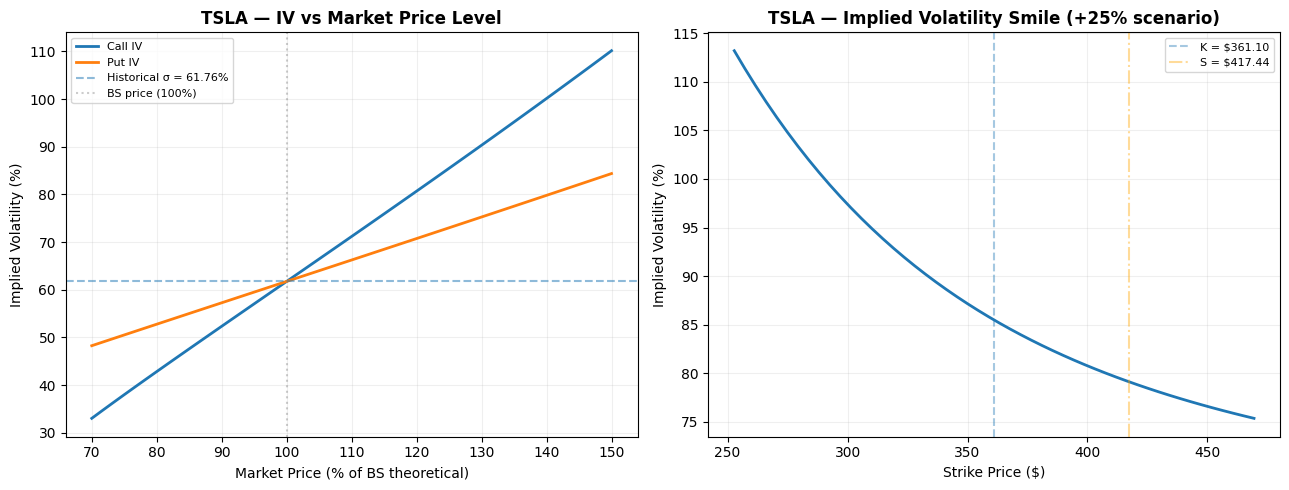


  INTERPRETATION
  Historical volatility:  61.76%
  IV call (+25%):         85.49% → market prices TSLA options
  as more volatile than historical data suggests.
  IV call (-25%):         38.00% → options appear cheap
  relative to historical vol.

  The IV smile (right chart) shows that a uniform +25% price
  bump produces different IVs across strikes — deep OTM/ITM
  options have higher IV than ATM, consistent with the
  volatility smile observed in real equity markets.


In [77]:
def bs_put_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * N(-d2) - S * N(-d1)

def implied_vol_bisection(target_price, price_fn, S, K, T, r,
                          sigma_low=1e-6, sigma_high=5.0, tol=1e-8, max_iter=200):
    """
    Bisection root finder: finds sigma such that price_fn(S,K,T,r,sigma) = target_price.
    Bisection is slower than Newton-Raphson but guaranteed to converge
    since vanilla option prices are monotonically increasing in sigma.
    """
    low, high = sigma_low, sigma_high
    for i in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = price_fn(S, K, T, r, mid) - target_price
        if abs(f_mid) < tol:
            return mid, i  # return iterations for audit
        if (price_fn(S, K, T, r, low) - target_price) * f_mid <= 0:
            high = mid
        else:
            low = mid
    return 0.5 * (low + high), max_iter

# ── Synthetic market prices ──
# +25% deviation (options appear expensive vs BS model)
deviation_up = 0.25
market_call_up = call_price * (1 + deviation_up)
market_put_up  = put_price * (1 + deviation_up)

# -25% deviation (options appear cheap vs BS model)
deviation_dn = -0.25
market_call_dn = call_price * (1 + deviation_dn)
market_put_dn  = put_price * (1 + deviation_dn)

# Solve for IV in all cases
iv_call_up, n_call_up = implied_vol_bisection(market_call_up, bs_call_price, S, K, T, r)
iv_put_up, n_put_up   = implied_vol_bisection(market_put_up, bs_put_price, S, K, T, r)
iv_call_dn, n_call_dn = implied_vol_bisection(market_call_dn, bs_call_price, S, K, T, r)
iv_put_dn, n_put_dn   = implied_vol_bisection(market_put_dn, bs_put_price, S, K, T, r)

print("=" * 65)
print(f"Q5 — Implied Volatility: {company_name} ({ticker})")
print("=" * 65)

print(f"\n  INPUTS")
print(f"  {'Historical σ (BS input):':.<40} {sigma_annual:.4f} ({sigma_annual*100:.2f}%)")
print(f"  {'BS call price:':.<40} ${call_price:.2f}")
print(f"  {'BS put price:':.<40} ${put_price:.2f}")

print(f"\n  SCENARIO 1: Market prices +{deviation_up*100:.0f}% above BS")
print(f"  {'Market call:':.<40} ${market_call_up:.2f}")
print(f"  {'Market put:':.<40} ${market_put_up:.2f}")
print(f"  {'IV call:':.<40} {iv_call_up:.4f} ({iv_call_up*100:.2f}%)")
print(f"  {'IV put:':.<40} {iv_put_up:.4f} ({iv_put_up*100:.2f}%)")
print(f"  {'Convergence (call):':.<40} {n_call_up} iterations")
print(f"  {'Convergence (put):':.<40} {n_put_up} iterations")

print(f"\n  SCENARIO 2: Market prices {deviation_dn*100:.0f}% below BS")
print(f"  {'Market call:':.<40} ${market_call_dn:.2f}")
print(f"  {'Market put:':.<40} ${market_put_dn:.2f}")
print(f"  {'IV call:':.<40} {iv_call_dn:.4f} ({iv_call_dn*100:.2f}%)")
print(f"  {'IV put:':.<40} {iv_put_dn:.4f} ({iv_put_dn*100:.2f}%)")
print(f"  {'Convergence (call):':.<40} {n_call_dn} iterations")
print(f"  {'Convergence (put):':.<40} {n_put_dn} iterations")

# ── Verification: reprice with IV to confirm ──
print(f"\n  VERIFICATION (reprice with IV)")
print(f"  {'':>25} {'Target':>10} {'Repriced':>10} {'Error':>10}")
print(f"  {'─'*25} {'─'*10} {'─'*10} {'─'*10}")
for label, target, iv, fn in [
    ("Call +25%", market_call_up, iv_call_up, bs_call_price),
    ("Put +25%", market_put_up, iv_put_up, bs_put_price),
    ("Call -25%", market_call_dn, iv_call_dn, bs_call_price),
    ("Put -25%", market_put_dn, iv_put_dn, bs_put_price),
]:
    repriced = fn(S, K, T, r, iv)
    print(f"  {label:>25} ${target:>9.4f} ${repriced:>9.4f} ${abs(target-repriced):>9.2e}")

# ── Why IV_call ≠ IV_put ──
parity_bs = call_price - put_price
parity_mkt_up = market_call_up - market_put_up
parity_theo = S - K * np.exp(-r * T)

print(f"\n  NOTE ON CALL vs PUT IV DIFFERENCE")
print(f"  {'C - P (BS prices):':.<40} ${parity_bs:.2f}")
print(f"  {'C - P (market +25%):':.<40} ${parity_mkt_up:.2f}")
print(f"  {'S - K×e^(-rT) (parity):':.<40} ${parity_theo:.2f}")
print(f"  The +25% bump applied to different absolute prices breaks")
print(f"  put-call parity, causing IV_call ≠ IV_put. In real markets,")
print(f"  IV differences across strikes form the volatility smile/skew.")

# ── Interpretation chart: IV vs market price ──
price_multipliers = np.linspace(0.7, 1.5, 50)
iv_calls = []
iv_puts = []
for m in price_multipliers:
    iv_c, _ = implied_vol_bisection(call_price * m, bs_call_price, S, K, T, r)
    iv_p, _ = implied_vol_bisection(put_price * m, bs_put_price, S, K, T, r)
    iv_calls.append(iv_c)
    iv_puts.append(iv_p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IV vs market price multiplier
axes[0].plot(price_multipliers * 100, [iv * 100 for iv in iv_calls], linewidth=2, label="Call IV")
axes[0].plot(price_multipliers * 100, [iv * 100 for iv in iv_puts], linewidth=2, label="Put IV")
axes[0].axhline(sigma_annual * 100, linestyle="--", alpha=0.5, label=f"Historical σ = {sigma_annual:.2%}")
axes[0].axvline(100, linestyle=":", alpha=0.4, color="gray", label="BS price (100%)")
axes[0].set_title(f"{ticker} — IV vs Market Price Level", fontweight="bold")
axes[0].set_xlabel("Market Price (% of BS theoretical)")
axes[0].set_ylabel("Implied Volatility (%)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# IV smile across strikes
K_range = np.linspace(K * 0.7, K * 1.3, 50)
iv_smile = []
for k in K_range:
    # Use +25% of BS price at each strike as "market price"
    bs_at_k = bs_call_price(S, k, T, r, sigma_annual)
    mkt_at_k = bs_at_k * 1.25
    iv_k, _ = implied_vol_bisection(mkt_at_k, bs_call_price, S, k, T, r)
    iv_smile.append(iv_k)

axes[1].plot(K_range, [iv * 100 for iv in iv_smile], linewidth=2)
axes[1].axvline(K, linestyle="--", alpha=0.4, label=f"K = ${K:.2f}")
axes[1].axvline(S, linestyle="-.", alpha=0.4, color="orange", label=f"S = ${S:.2f}")
axes[1].set_title(f"{ticker} — Implied Volatility Smile (+25% scenario)", fontweight="bold")
axes[1].set_xlabel("Strike Price ($)")
axes[1].set_ylabel("Implied Volatility (%)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

print(f"\n  INTERPRETATION")
print(f"  Historical volatility:  {sigma_annual:.2%}")
print(f"  IV call (+25%):         {iv_call_up:.2%} → market prices {ticker} options")
print(f"  as more volatile than historical data suggests.")
print(f"  IV call (-25%):         {iv_call_dn:.2%} → options appear cheap")
print(f"  relative to historical vol.")
print(f"\n  The IV smile (right chart) shows that a uniform +25% price")
print(f"  bump produces different IVs across strikes — deep OTM/ITM")
print(f"  options have higher IV than ATM, consistent with the")
print(f"  volatility smile observed in real equity markets.")

# Q6 - Stochastic Processes and Monte Carlo Pricing

### (a) Geometric Brownian Motion (GBM)

In the Black–Scholes setting, the underlying price $S_t$ follows a **Geometric Brownian Motion (GBM)** under the risk-neutral measure:

$$
dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t
$$

where $r$ is the risk-free rate, $q$ is the dividend yield (we set $q=0$ below since we used close prices without explicit dividend modeling), and $W_t$ is a standard Brownian motion.

The exact solution implies:

$$
S_T = S_0 \exp\left((r-q-\tfrac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z\right),
\qquad Z \sim \mathcal{N}(0,1)
$$


### (b) Monte Carlo price for a European call (20,000 simulations)

We estimate the option price using the Monte Carlo estimator:

$$
C \approx e^{-rT}\mathbb{E}\left[(S_T-K)^+\right]
$$


### (c) Local volatility

A **local volatility** model replaces the constant volatility $\sigma$ with a state- and time-dependent function $\sigma_{loc}(S,t)$:

$$
dS_t = (r-q)S_t\,dt + \sigma_{loc}(S_t,t)S_t\,dW_t
$$

A popular way to infer $\sigma_{loc}$ from option prices is the **Dupire formula**, based on call prices $C(K,T)$.


### (d) Monte Carlo under local volatility (20,000 simulations)

We proceed as follows:

1. Build a small synthetic option surface around $(K,T)$ using Black–Scholes call prices.  
2. Approximate partial derivatives using **finite differences**.  
3. Compute $\sigma_{loc}(K,T)$ and use it as a constant local volatility level for simulation.

This final step is a simplifying assumption; it keeps the local-volatility Monte Carlo framework distinct from the pure GBM case through a different volatility level.

Q6b — Monte Carlo Call Price (GBM
Simulations: 20,000
MC call price: $132.9945
Std. error:    $1.7192
BS call (Q3b): $130.9280  (benchmark)


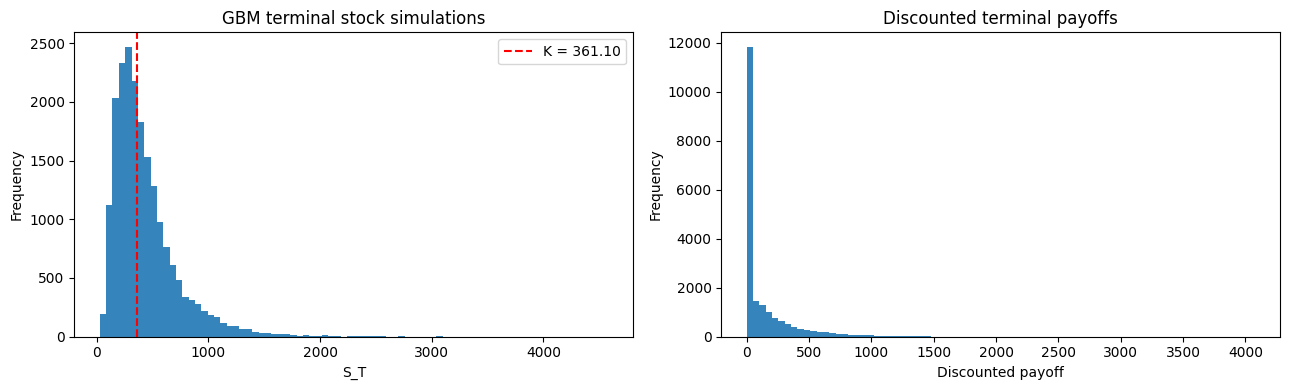

In [78]:
# Monte Carlo pricing under GBM

q = 0.0  # dividend yield
n_sims = 20_000
Z = np.random.normal(size=n_sims)

S_T_gbm = S * np.exp((r - q - 0.5 * sigma_annual**2) * T + sigma_annual * np.sqrt(T) * Z)
payoff_call_gbm = np.maximum(S_T_gbm - K, 0.0)
mc_call_gbm = np.exp(-r * T) * payoff_call_gbm.mean()
mc_call_gbm_se = np.exp(-r * T) * payoff_call_gbm.std(ddof=1) / np.sqrt(n_sims)

import matplotlib.pyplot as plt

# plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(S_T_gbm, bins=80, alpha=0.9)
axes[0].axvline(K, color="red", linestyle="--", label=f"K = {K:.2f}")
axes[0].set_title("GBM terminal stock simulations")
axes[0].set_xlabel("S_T")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(np.exp(-r * T) * payoff_call_gbm, bins=80, alpha=0.9)
axes[1].set_title("Discounted terminal payoffs")
axes[1].set_xlabel("Discounted payoff")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

print("Q6b — Monte Carlo Call Price (GBM")
print("=" * 70)
print(f"Simulations: {n_sims:,}")
print(f"MC call price: ${mc_call_gbm:.4f}")
print(f"Std. error:    ${mc_call_gbm_se:.4f}")
print(f"BS call (Q3b): ${call_price:.4f}  (benchmark)")


## (c) - Local Volatility via Finite Differences (Dupire Approximation)

We estimate the **local volatility** at the point $(K,T)$ by approximating derivatives of the call price with **finite differences**.

### Finite-Difference Grid
Evaluate nearby prices:
- $C(K+\Delta K, T)$, $C(K-\Delta K, T)$
- $C(K, T+\Delta T)$, $C(K, T-\Delta T)$

Bump sizes:
$$
\Delta K = 0.01K, \qquad
\Delta T = \min\!\left(\frac{1}{12}, \frac{T}{2}\right)
$$

### Derivative Approximations
$$
\frac{\partial C}{\partial T} \approx
\frac{C(K,T+\Delta T) - C(K,T-\Delta T)}{2\Delta T}
$$

$$
\frac{\partial C}{\partial K} \approx
\frac{C(K+\Delta K,T) - C(K-\Delta K,T)}{2\Delta K}
$$

$$
\frac{\partial^2 C}{\partial K^2} \approx
\frac{C(K+\Delta K,T) - 2C(K,T) + C(K-\Delta K,T)}{\Delta K^2}
$$

### Dupire Local Volatility
Let $\mu_{rn} = r - q$. The local variance is

$$
\sigma_{\text{loc}}^2(K,T)
=
\frac{
\frac{\partial C}{\partial T} + (r-q)K\frac{\partial C}{\partial K} + qC
}{
\tfrac{1}{2}K^2 \frac{\partial^2 C}{\partial K^2}
}
$$

If the estimate becomes non-positive due to numerical noise, it is **floored to a small positive value** before computing $\sigma_{\text{loc}}$.

In [79]:
# Local volatility via finite differences (Dupire-style)
dK = 0.01 * K
dT = min(1.0/12.0, 0.5*T)  # keep T-dT positive

def C(K_, T_):
    return bs_call_price(S, K_, T_, r, sigma_annual)

C_Kp = C(K + dK, T)
C_Km = C(K - dK, T)
C_Tp = C(K, T + dT)
C_Tm = C(K, T - dT)

# Finite-difference partial derivatives:
dC_dT = (C_Tp - C_Tm) / (2.0 * dT)
dC_dK = (C_Kp - C_Km) / (2.0 * dK)
d2C_dK2 = (C_Kp - 2.0 * call_price + C_Km) / (dK**2)

# Under risk-neutral pricing, drift is (r-q).
mu_rn = (r - q)

# Dupire local volatility (one common form, with q=0):
#   σ_loc^2(K,T) = [∂C/∂T + (r-q)K ∂C/∂K + q C] / [0.5 K^2 ∂²C/∂K²]
numerator = dC_dT + mu_rn * K * dC_dK + q * call_price
denominator = 0.5 * (K**2) * d2C_dK2
sigma_loc_sq = numerator / denominator

# Numerical guard: sigma_loc_sq should be positive; if not, we clip it
sigma_loc = np.sqrt(max(sigma_loc_sq, 1e-12))

print("Q6c — Local Volatility at (K,T) from finite differences")
print("=" * 80)
print(f"ΔK = {dK:.4f}, ΔT = {dT:.6f} years")
print(f"∂C/∂T   ≈ {dC_dT:.6f}")
print(f"∂C/∂K   ≈ {dC_dK:.6f}")
print(f"∂²C/∂K² ≈ {d2C_dK2:.8f}")
print("-" * 80)
print(f"sigma_loc^2(K,T) ≈ {sigma_loc_sq:.6f}")
print(f"sigma_loc(K,T)   ≈ {sigma_loc:.6f}  ({sigma_loc*100:.2f}%)")


Q6c — Local Volatility at (K,T) from finite differences
ΔK = 3.6110, ΔT = 0.083333 years
∂C/∂T   ≈ 48.899022
∂C/∂K   ≈ -0.476000
∂²C/∂K² ≈ 0.00172837
--------------------------------------------------------------------------------
sigma_loc^2(K,T) ≈ 0.381782
sigma_loc(K,T)   ≈ 0.617885  (61.79%)


## (d) - Monte Carlo Call Pricing under (Simplified) Local Volatility

We simulate the asset price dynamics under the process

$$
dS_t = (r - q) S_t \, dt + \sigma_{loc} S_t \, dW_t
$$

using the **exact GBM-style terminal solution**, but replacing the volatility parameter with  $\sigma = \sigma_{loc}$.

In a full **local volatility model**, the volatility is a function of both the asset price and time:

$$
\sigma_{loc} = \sigma_{loc}(S_t, t)
$$

However, for this exercise we simplify the framework by keeping the local volatility **constant**, using the level estimated in **Q6c**.

In [80]:
Z2 = np.random.normal(size=n_sims)
S_T_lv = S * np.exp((r - q - 0.5 * sigma_loc**2) * T + sigma_loc * np.sqrt(T) * Z2)
payoff_call_lv = np.maximum(S_T_lv - K, 0.0)
mc_call_lv = np.exp(-r * T) * payoff_call_lv.mean()
mc_call_lv_se = np.exp(-r * T) * payoff_call_lv.std(ddof=1) / np.sqrt(n_sims)

print("Q6d — Monte Carlo Call Price (Local Vol, simplified)")
print("=" * 80)
print(f"Simulations: {n_sims:,}")
print(f"Local vol used: {sigma_loc:.4f} ({sigma_loc*100:.2f}%)")
print(f"MC call price:  ${mc_call_lv:.4f}")
print(f"Std. error:     ${mc_call_lv_se:.4f}")
print(f"MC (GBM):       ${mc_call_gbm:.4f}  (from Q6b)")


Q6d — Monte Carlo Call Price (Local Vol, simplified)
Simulations: 20,000
Local vol used: 0.6179 (61.79%)
MC call price:  $132.2497
Std. error:     $1.7573
MC (GBM):       $132.9945  (from Q6b)


# Q7 - Hedging Concepts
**Hedging** is the act of taking positions designed to **reduce** (not eliminate) exposure to a risk factor.

### What is hedging?
Given a portfolio value $\pi$ that depends on market variables (e.g., $S$, $\sigma$, $r$), **hedging** aims to make $\pi$ less sensitive to these variables. This is typically achieved by adding financial instruments whose **Greeks** offset those of the portfolio.

### Why hedge?
- Risk management: stabilize P&L, control downside, meet risk limits.
- Business necessity: many firms must hedge inputs/outputs (FX, commodities, rates).
- Capital efficiency: reduce tail risk and regulatory capital usage.

### Who hedges?
- Market makers and option desks (dynamic hedging of Greeks).
- Corporates (FX/rates/commodity exposures).
- Asset managers / hedge funds (risk budgeting, factor hedging).

### Main approaches
1) **Static hedging**: hold a hedge to maturity (rare for options).
2) **Dynamic hedging**: rebalance through time (e.g., delta hedging).
3) **Greek hedging**: target specific sensitivities (delta-, gamma-, vega-neutral, etc.).
4) **Scenario / stress hedging**: hedge against large moves rather than infinitesimal changes.


# Q8 - Delta Hedging

In [81]:
# Delta-neutral portfolio (Covered Call)
# Strategy: Long 25,000 shares + Short N call options
# Portfolio delta = 25000 * 1 + N_options * (-delta_call) = 0

n_shares = 25000
delta_call = bs_delta_call(S, K, T, r, sigma_annual)
gamma_call = bs_gamma(S, K, T, r, sigma_annual)

# Number of calls to short for delta-neutral
n_options = n_shares / delta_call

In [82]:
print("Q8a -- Delta-Neutral Portfolio (Covered Call)")
print("=" * 55)
print(f"  Position:          Long {n_shares:,} shares of {ticker}")
print(f"  Strategy:          Covered Call (short calls)")
print(f"  Call delta:        {delta_call:.6f}")
print(f"  Call gamma:        {gamma_call:.6f}")
print(f"  Options to short:  {n_options:.2f} calls")
print(f"  Rounded:           {round(n_options)} calls")
print(f"\n  Verification:")
print(f"  Portfolio delta = {n_shares} * 1 + {round(n_options)} * (-{delta_call:.4f})")
portfolio_delta = n_shares - round(n_options) * delta_call
print(f"  Portfolio delta = {portfolio_delta:.4f}")
if abs(portfolio_delta) < 1:
    print(f"  ≈ 0 (residual due to rounding of {n_options:.2f} -> {round(n_options)})")
else:
    print(f"  Non-negligible residual -> consider adjusting option count")
print(f"\n  Interpretation:")
print(f"  We need to short {round(n_options)} call options to offset the delta of our {n_shares:,} share long position.")
print(f"  Since each call has delta {delta_call:.4f} < 1, we need more options than shares to achieve neutrality.")

Q8a -- Delta-Neutral Portfolio (Covered Call)
  Position:          Long 25,000 shares of TSLA
  Strategy:          Covered Call (short calls)
  Call delta:        0.725392
  Call gamma:        0.001293
  Options to short:  34464.13 calls
  Rounded:           34464 calls

  Verification:
  Portfolio delta = 25000 * 1 + 34464 * (-0.7254)
  Portfolio delta = 0.0909
  ≈ 0 (residual due to rounding of 34464.13 -> 34464)

  Interpretation:
  We need to short 34464 call options to offset the delta of our 25,000 share long position.
  Since each call has delta 0.7254 < 1, we need more options than shares to achieve neutrality.


In [83]:
# Q8b -- Effect of +$1.5 price increase
dS = 1.5
S_new = S + dS

# New call price and delta after the move
call_price_new = BS_CALL(S_new, K, T, r, sigma_annual)
delta_call_new = bs_delta_call(S_new, K, T, r, sigma_annual)

# P&L of each leg
pnl_shares = n_shares * dS
pnl_options = -round(n_options) * (call_price_new - call_price)
pnl_total = pnl_shares + pnl_options

In [84]:
print("Q8b -- Effect of +$1.5 Price Increase")
print("=" * 55)
print(f"  New stock price:   ${S_new:.2f} (was ${S:.2f})")
print(f"  New call price:    ${call_price_new:.2f} (was ${call_price:.2f})")
print(f"\n  P&L breakdown:")
print(f"  Shares:   {n_shares:,} × ${dS} = +${pnl_shares:,.2f}")
print(f"  Options:  -{round(n_options)} × (${call_price_new:.2f} - ${call_price:.2f}) = ${pnl_options:,.2f}")
print(f"  Total P&L: ${pnl_total:,.2f}")
print(f"\n  Interpretation:")
print(f"  The portfolio is approximately delta-neutral, so the gains on shares are mostly offset by losses on short calls.")
print(f"  The small residual P&L (${pnl_total:,.2f}) comes from the gamma effect (convexity).")

Q8b -- Effect of +$1.5 Price Increase
  New stock price:   $418.94 (was $417.44)
  New call price:    $132.02 (was $130.93)

  P&L breakdown:
  Shares:   25,000 × $1.5 = +$37,500.00
  Options:  -34464 × ($132.02 - $130.93) = $-37,549.89
  Total P&L: $-49.89

  Interpretation:
  The portfolio is approximately delta-neutral, so the gains on shares are mostly offset by losses on short calls.
  The small residual P&L ($-49.89) comes from the gamma effect (convexity).


In [85]:
# Delta after move + rebalancing
portfolio_delta_new = n_shares - round(n_options) * delta_call_new

# Rebalancing: adjust number of options
n_options_new = n_shares / delta_call_new
adjustment = n_options_new - round(n_options)

In [86]:
print("Q8c — Delta After Move & Rebalancing")
print("=" * 55)
print(f"  Old call delta:      {delta_call:.6f}")
print(f"  New call delta:      {delta_call_new:.6f}")
print(f"  Delta change:        {delta_call_new - delta_call:.6f}")
print(f"\n  Portfolio delta after move:")
print(f"  = {n_shares} - {round(n_options)} × {delta_call_new:.4f}")
print(f"  = {portfolio_delta_new:.4f}")
print(f"\n  The portfolio is no longer delta-neutral.")
print(f"\n  Rebalancing:")
print(f"  New options needed:  {n_options_new:.2f}")
print(f"  Currently short:     {round(n_options)}")

if adjustment > 0:
    print(f"  Action: short {adjustment:.2f} additional calls")
else:
    print(f"  Action: buy back {abs(adjustment):.2f} calls")

print(f"\n  Interpretation:")
if portfolio_delta_new < 0:
    print(f"  After the ${dS} increase, call delta rose from {delta_call:.4f}")
    print(f"  to {delta_call_new:.4f}. Each short call now carries more")
    print(f"  negative delta, making the portfolio over-hedged")
    print(f"  (delta = {portfolio_delta_new:.2f} < 0).")
    print(f"  To restore neutrality, we buy back {abs(round(adjustment))}")
    print(f"  calls, reducing the short position from {round(n_options)}")
    print(f"  to {round(n_options_new)} calls.")
else:
    print(f"  After the ${dS} increase, the portfolio is under-hedged")
    print(f"  (delta = {portfolio_delta_new:.2f} > 0).")
    print(f"  To restore neutrality, we short {round(adjustment)}")
    print(f"  additional calls.")

Q8c — Delta After Move & Rebalancing
  Old call delta:      0.725392
  New call delta:      0.727325
  Delta change:        0.001933

  Portfolio delta after move:
  = 25000 - 34464 × 0.7273
  = -66.5324

  The portfolio is no longer delta-neutral.

  Rebalancing:
  New options needed:  34372.52
  Currently short:     34464
  Action: buy back 91.48 calls

  Interpretation:
  After the $1.5 increase, call delta rose from 0.7254
  to 0.7273. Each short call now carries more
  negative delta, making the portfolio over-hedged
  (delta = -66.53 < 0).
  To restore neutrality, we buy back 91
  calls, reducing the short position from 34464
  to 34373 calls.


### Divers

Q8 — Dynamic Hedge Verification (Historical)

  Test period: last 30 trading days
          Date    Price       dS      T     PnL Tot   Gamma PnL        Cumul     Delta
  ------------  -------  -------  -----  ----------  ----------  -----------  --------
  2026-01-05   451.67   +13.60  0.131     -47,702      -6,628      -47,702     -5033
  2026-01-06   432.96   -18.71  0.127        +503     -13,332      -47,199     +1186
  2026-01-07   431.41    -1.55  0.123     +12,541         -98      -34,659       +41
  2026-01-08   435.80    +4.39  0.119     +11,563        -751      -23,096      -440
  2026-01-09   445.01    +9.21  0.115      +8,204      -2,871      -14,891      -757
  2026-01-12   448.96    +3.95  0.111     +10,126        -483       -4,765      -346
  2026-01-13   447.20    -1.76  0.107     +10,549         -97       +5,784       +12
  2026-01-14   439.20    -8.00  0.103      +9,357      -2,262      +15,140      +432
  2026-01-15   438.57    -0.63  0.099     +11,715         -14   

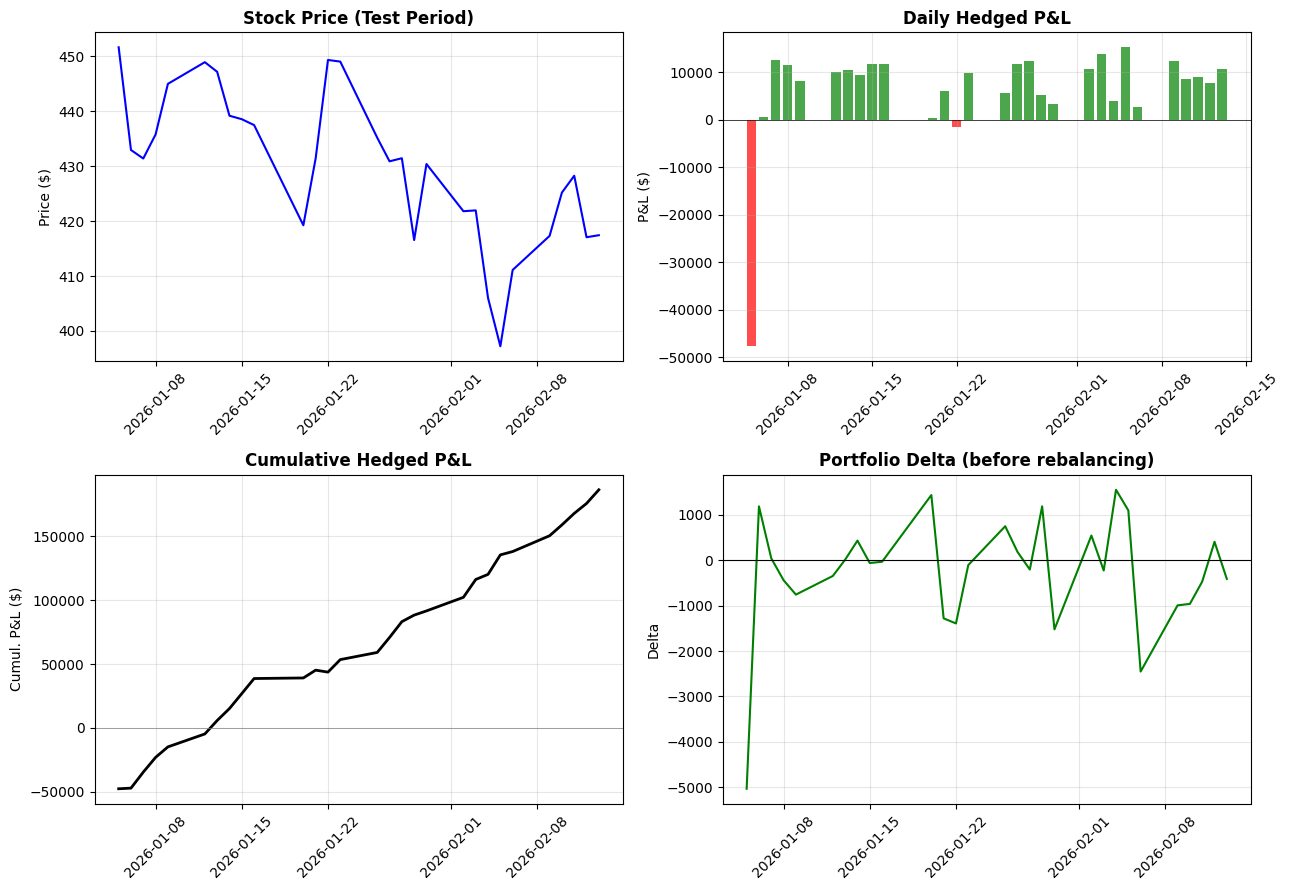

In [87]:
# Q8 — Dynamic Hedge Verification (with T decay)
# ============================================================
print("Q8 — Dynamic Hedge Verification (Historical)")
print("=" * 55)

n_days_test = 30
test_prices = df["Close"].iloc[-n_days_test:].values
test_dates = df["Date"].iloc[-n_days_test:].values

results = []
current_n_options = round(n_options)

# T decays each day (count business days remaining)
total_bdays = 252  # 1 year
days_elapsed_start = len(df) - n_days_test

for i in range(1, len(test_prices)):
    S_prev = test_prices[i - 1]
    S_curr = test_prices[i]
    dS_actual = S_curr - S_prev

    # Time to maturity decreases each day
    T_prev = max((total_bdays - (days_elapsed_start + i - 1)) / 252, 1/252)
    T_curr = max((total_bdays - (days_elapsed_start + i)) / 252, 1/252)

    call_prev = BS_CALL(S_prev, K, T_prev, r, sigma_annual)
    call_curr = BS_CALL(S_curr, K, T_curr, r, sigma_annual)
    delta_curr = bs_delta_call(S_curr, K, T_curr, r, sigma_annual)
    gamma_curr = bs_gamma(S_curr, K, T_curr, r, sigma_annual)

    pnl_shares = n_shares * dS_actual
    pnl_options = -current_n_options * (call_curr - call_prev)
    pnl_total = pnl_shares + pnl_options
    pf_delta = n_shares - current_n_options * delta_curr

    # Theoretical gamma P&L for comparison
    gamma_pnl = -0.5 * current_n_options * gamma_curr * dS_actual**2

    results.append({
        "date": test_dates[i],
        "price": S_curr,
        "dS": dS_actual,
        "T": T_curr,
        "pnl_shares": pnl_shares,
        "pnl_options": pnl_options,
        "pnl_total": pnl_total,
        "gamma_pnl": gamma_pnl,
        "pf_delta": pf_delta,
        "n_options": current_n_options
    })

    # Rebalance
    current_n_options = round(n_shares / delta_curr)

res = pd.DataFrame(results)
res["cumul_pnl"] = res["pnl_total"].cumsum()

print(f"\n  Test period: last {n_days_test} trading days")
print(f"  {'Date':>12}  {'Price':>7}  {'dS':>7}  {'T':>5}  {'PnL Tot':>10}  {'Gamma PnL':>10}  {'Cumul':>11}  {'Delta':>8}")
print(f"  {'-'*12}  {'-'*7}  {'-'*7}  {'-'*5}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*8}")
for _, row in res.iterrows():
    d = pd.Timestamp(row["date"]).strftime("%Y-%m-%d")
    print(f"  {d}  {row['price']:>7.2f}  {row['dS']:>+7.2f}  {row['T']:.3f}  {row['pnl_total']:>+10,.0f}  {row['gamma_pnl']:>+10,.0f}  {row['cumul_pnl']:>+11,.0f}  {row['pf_delta']:>+8.0f}")

print(f"\n  Summary:")
print(f"  Cumulative P&L:       ${res['cumul_pnl'].iloc[-1]:>+12,.2f}")
print(f"  Sum of gamma P&L:     ${res['gamma_pnl'].sum():>+12,.2f}")
print(f"  Mean |daily P&L|:     ${res['pnl_total'].abs().mean():>12,.2f}")
print(f"  Mean |Pf Delta|:      {res['pf_delta'].abs().mean():>12.2f}")
print(f"\n  Interpretation:")
print(f"  The delta hedge effectively neutralizes first-order")
print(f"  price risk (mean |delta| = {res['pf_delta'].abs().mean():.0f} vs 25,000 shares).")
print(f"  The residual losses come from the gamma (convexity)")
print(f"  exposure inherent to the covered call strategy.")
print(f"  Being short gamma means large moves in either direction")
print(f"  generate losses proportional to dS². This is partially")
print(f"  offset by theta income (time decay of short options).")
print(f"  To eliminate gamma risk, a gamma hedge (Q9) is needed.")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Price path
axes[0, 0].plot(res["date"], res["price"], "b-", linewidth=1.5)
axes[0, 0].set_title("Stock Price (Test Period)", fontweight="bold")
axes[0, 0].set_ylabel("Price ($)")
axes[0, 0].grid(True, alpha=0.3)

# Daily P&L
axes[0, 1].bar(res["date"], res["pnl_total"], color=["green" if x >= 0 else "red" for x in res["pnl_total"]], alpha=0.7)
axes[0, 1].axhline(0, color="black", linewidth=0.5)
axes[0, 1].set_title("Daily Hedged P&L", fontweight="bold")
axes[0, 1].set_ylabel("P&L ($)")
axes[0, 1].grid(True, alpha=0.3)

# Cumulative P&L
axes[1, 0].plot(res["date"], res["cumul_pnl"], "k-", linewidth=2)
axes[1, 0].axhline(0, color="gray", linewidth=0.5)
axes[1, 0].set_title("Cumulative Hedged P&L", fontweight="bold")
axes[1, 0].set_ylabel("Cumul. P&L ($)")
axes[1, 0].grid(True, alpha=0.3)

# Portfolio delta over time
axes[1, 1].plot(res["date"], res["pf_delta"], "g-", linewidth=1.5)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Portfolio Delta (before rebalancing)", fontweight="bold")
axes[1, 1].set_ylabel("Delta")
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The delta hedge eliminates directional risk, but you're still exposed to gamma. Since you're short calls (covered call), you're short gamma — meaning you lose money on large moves in either direction.

# Q9 - Gamma Hedging

**Delta hedging** removes the *first-order* sensitivity of a portfolio to the underlying price $S$. However, when $S$ moves, the **Delta itself changes**.

**Gamma hedging** addresses this by neutralizing the portfolio’s curvature with respect to $S$:

$$
\Gamma_{\text{portfolio}} = \sum_i n_i \Gamma_i
$$

The goal is to construct a **delta–gamma neutral** portfolio using:

- the **underlying stock** ($\Delta = 1,\ \Gamma = 0$),
- the **call option from Q3b** (Option 1),
- a second **additional option** (Option 2).

## Data Source Note

In practice, **Option 2** would be selected from a live **option chain** (e.g., market data providers or exchange feeds).  
For this exercise, we instead **specify Option 2 parameters directly** and compute its Greeks using the **Black–Scholes model**.

In [88]:
# Build a delta-gamma neutral position

# Portfolio setup (same as Q8a): long 25,000 shares
n_shares = 25_000

# Option 1: the Q3b call (same K, T)
K1, T1 = K, T
delta1 = delta_call
gamma1 = gamma_call

# Option 2: a "random" call (example choice)
# Logical choice: different strike and maturity to ensure a different gamma.
K2 = 1.10 * K          # 10% higher strike
T2 = 0.50 * T          # 6 months if T=1 year
sigma2 = sigma_annual  # use same vol estimate for a self-contained notebook
d1_2, d2_2 = bs_d1_d2(S, K2, T2, r, sigma2)
delta2 = N(d1_2)
gamma2 = norm.pdf(d1_2) / (S * sigma2 * np.sqrt(T2))

# We solve for n1 and n2 (number of options) such that:
#   Delta_total = n_shares*1 + n1*delta1 + n2*delta2 = 0
#   Gamma_total =            n1*gamma1 + n2*gamma2 = 0
#
# positive n means LONG the option. Negative means SHORT.

A = np.array([[delta1, delta2],
              [gamma1, gamma2]], dtype=float)
b = np.array([-n_shares, 0.0], dtype=float)

n1, n2 = np.linalg.solve(A, b)

delta_total = n_shares + n1*delta1 + n2*delta2
gamma_total = n1*gamma1 + n2*gamma2

print("Q9a — Delta-Gamma Neutral Construction")
print("=" * 85)
print("Option 1 (Q3b call):")
print(f"  K1={K1:.2f}, T1={T1:.2f}y, sigma={sigma_annual:.4f}, delta1={delta1:.6f}, gamma1={gamma1:.8f}")
print("Option 2 (example 'random' call):")
print(f"  K2={K2:.2f}, T2={T2:.2f}y, sigma={sigma2:.4f}, delta2={delta2:.6f}, gamma2={gamma2:.8f}")
print("-" * 85)
print("Holdings that make the portfolio locally delta- and gamma-neutral:")
print(f"  Shares:  +{n_shares:,}")
print(f"  Option 1: {n1:,.2f} contracts")
print(f"  Option 2: {n2:,.2f} contracts")
print("-" * 85)
print(f"Check: Delta_total ≈ {delta_total:.6f}")
print(f"Check: Gamma_total ≈ {gamma_total:.10f}")


Q9a — Delta-Gamma Neutral Construction
Option 1 (Q3b call):
  K1=361.10, T1=1.00y, sigma=0.6176, delta1=0.725392, gamma1=0.00129332
Option 2 (example 'random' call):
  K2=397.21, T2=0.50y, sigma=0.6176, delta2=0.644780, gamma2=0.00204261
-------------------------------------------------------------------------------------
Holdings that make the portfolio locally delta- and gamma-neutral:
  Shares:  +25,000
  Option 1: -78,830.41 contracts
  Option 2: 49,913.06 contracts
-------------------------------------------------------------------------------------
Check: Delta_total ≈ 0.000000
Check: Gamma_total ≈ -0.0000000000


In [89]:
# Can we maintain a delta-gamma neutral position after S moves?

# After a move in S, deltas and gammas change, so a previously neutral portfolio is no longer neutral.
# We illustrate this with a +$1.5 move (same shock used in Q8b).

dS = 1.5
S_new = S + dS

# Recompute greeks at the new spot for both options
d1_1_new, d2_1_new = bs_d1_d2(S_new, K1, T1, r, sigma_annual)
delta1_new = N(d1_1_new)
gamma1_new = norm.pdf(d1_1_new) / (S_new * sigma_annual * np.sqrt(T1))

d1_2_new, d2_2_new = bs_d1_d2(S_new, K2, T2, r, sigma2)
delta2_new = N(d1_2_new)
gamma2_new = norm.pdf(d1_2_new) / (S_new * sigma2 * np.sqrt(T2))

delta_total_new = n_shares + n1*delta1_new + n2*delta2_new
gamma_total_new = n1*gamma1_new + n2*gamma2_new

print("Q9b — After a +$1.5 move, neutrality breaks (because Greeks change).")
print("=" * 90)
print(f"New spot: S' = {S_new:.2f} (was {S:.2f})")
print("-" * 90)
print(f"Old deltas:  delta1={delta1:.6f}, delta2={delta2:.6f}")
print(f"New deltas:  delta1'={delta1_new:.6f}, delta2'={delta2_new:.6f}")
print(f"Old gammas:  gamma1={gamma1:.8f}, gamma2={gamma2:.8f}")
print(f"New gammas:  gamma1'={gamma1_new:.8f}, gamma2'={gamma2_new:.8f}")
print("-" * 90)
print(f"Portfolio after move: Delta ≈ {delta_total_new:.2f}, Gamma ≈ {gamma_total_new:.6f}")

# Rebalancing: solve again at S_new for new (n1', n2') that restores neutrality
A_new = np.array([[delta1_new, delta2_new],
                  [gamma1_new, gamma2_new]], dtype=float)
b_new = np.array([-n_shares, 0.0], dtype=float)

n1_reb, n2_reb = np.linalg.solve(A_new, b_new)

print("-" * 90)
print("One way to maintain delta-gamma neutrality is to rebalance the option quantities:")
print(f"  New Option 1 holding: {n1_reb:,.2f}  (change = {n1_reb - n1:,.2f})")
print(f"  New Option 2 holding: {n2_reb:,.2f}  (change = {n2_reb - n2:,.2f})")


Q9b — After a +$1.5 move, neutrality breaks (because Greeks change).
New spot: S' = 418.94 (was 417.44)
------------------------------------------------------------------------------------------
Old deltas:  delta1=0.725392, delta2=0.644780
New deltas:  delta1'=0.727325, delta2'=0.647834
Old gammas:  gamma1=0.00129332, gamma2=0.00204261
New gammas:  gamma1'=0.00128419, gamma2'=0.00202903
------------------------------------------------------------------------------------------
Portfolio after move: Delta ≈ 0.03, Gamma ≈ 0.041741
------------------------------------------------------------------------------------------
One way to maintain delta-gamma neutrality is to rebalance the option quantities:
  New Option 1 holding: -78,788.51  (change = 41.90)
  New Option 2 holding: 49,865.97  (change = -47.09)


###Divers

In [90]:
print(f"\n  INTERPRETATION")
print(f"  Delta hedging alone (Q8) requires only one instrument (the stock or one option), but cannot control gamma.")
print(f"  Delta-gamma neutrality requires TWO option positions because we have two constraints (Δ=0 and Γ=0) to satisfy simultaneously.")
print(f"  The stock cannot help with gamma since Γ_stock = 0.")
print(f"\n  Option 2 (K2=${K2:.2f}, T2={T2:.2f}y) was chosen with a different strike and maturity to ensure gamma2 ({gamma2:.6f}) differs from gamma1 ({gamma1:.6f}), making the system solvable.")
print(f"  If gamma1 = gamma2, the matrix would be singular (no solution).")


  INTERPRETATION
  Delta hedging alone (Q8) requires only one instrument (the stock or one option), but cannot control gamma.
  Delta-gamma neutrality requires TWO option positions because we have two constraints (Δ=0 and Γ=0) to satisfy simultaneously.
  The stock cannot help with gamma since Γ_stock = 0.

  Option 2 (K2=$397.21, T2=0.50y) was chosen with a different strike and maturity to ensure gamma2 (0.002043) differs from gamma1 (0.001293), making the system solvable.
  If gamma1 = gamma2, the matrix would be singular (no solution).


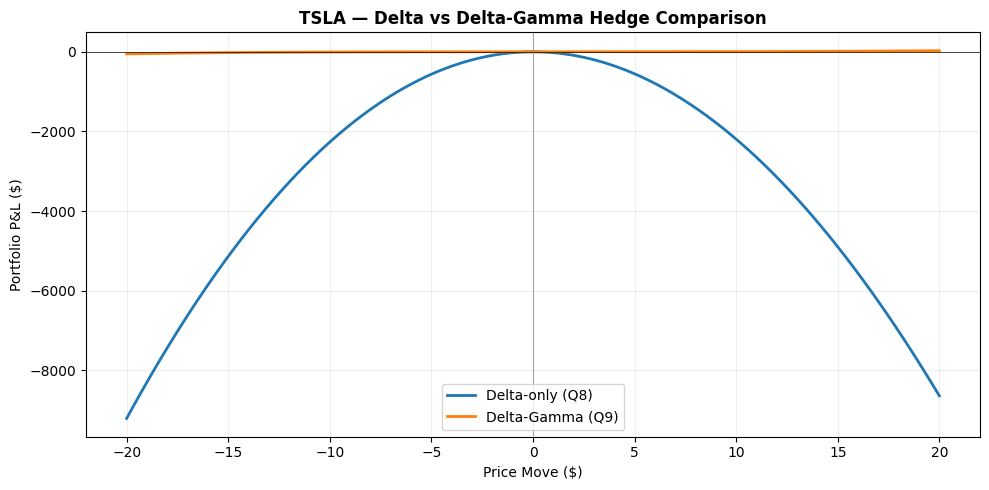


  The delta-gamma hedge (blue) is flatter than delta-only (orange)
  for large moves, confirming gamma neutrality reduces curvature risk.
  Residual P&L comes from third-order effects (speed/charm).


In [91]:
# Verify delta-gamma hedge vs delta-only hedge
test_moves = np.linspace(-20, 20, 200)
pnl_delta_only = []
pnl_delta_gamma = []

for ds in test_moves:
    S_test = S + ds
    c1_new = BS_CALL(S_test, K1, T1, r, sigma_annual)
    c2_new = BS_CALL(S_test, K2, T2, r, sigma_annual)

    # Delta-only (from Q8a)
    pnl_do = n_shares * ds - round(n_options) * (c1_new - call_price)
    pnl_delta_only.append(pnl_do)

    # Delta-gamma
    c1_old = BS_CALL(S, K1, T1, r, sigma_annual)
    c2_old = BS_CALL(S, K2, T2, r, sigma_annual)
    pnl_dg = n_shares * ds + n1 * (c1_new - c1_old) + n2 * (c2_new - c2_old)
    pnl_delta_gamma.append(pnl_dg)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_moves, pnl_delta_only, linewidth=2, label="Delta-only (Q8)")
ax.plot(test_moves, pnl_delta_gamma, linewidth=2, label="Delta-Gamma (Q9)")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_title(f"{ticker} — Delta vs Delta-Gamma Hedge Comparison", fontweight="bold")
ax.set_xlabel("Price Move ($)")
ax.set_ylabel("Portfolio P&L ($)")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\n  The delta-gamma hedge (blue) is flatter than delta-only (orange)")
print(f"  for large moves, confirming gamma neutrality reduces curvature risk.")
print(f"  Residual P&L comes from third-order effects (speed/charm).")

In [92]:
print(f"  Q9b CONCLUSION")
print(f"  Yes, it is possible to maintain delta-gamma neutrality, but it requires continuous rebalancing of both option positions.")
print(f"  After a ${dS} move:")
print(f"    - Portfolio delta drifted to {delta_total_new:.2f} (from 0)")
print(f"    - Portfolio gamma drifted to {gamma_total_new:.6f} (from 0)")
print(f"    - Rebalancing requires adjusting only {abs(n1_reb-n1):.0f} + {abs(n2_reb-n2):.0f} contracts (small vs total position of {abs(n1):.0f} + {abs(n2):.0f})")
print(f"  The small adjustments confirm the hedge is stable and practical.")

  Q9b CONCLUSION
  Yes, it is possible to maintain delta-gamma neutrality, but it requires continuous rebalancing of both option positions.
  After a $1.5 move:
    - Portfolio delta drifted to 0.03 (from 0)
    - Portfolio gamma drifted to 0.041741 (from 0)
    - Rebalancing requires adjusting only 42 + 47 contracts (small vs total position of 78830 + 49913)
  The small adjustments confirm the hedge is stable and practical.


# Q10 - Vega Hedging

In [93]:
# Call spread: Long call at K1 = K, Short call at K2 = 1.3 * K
K1 = K
K2 = 1.3 * K

# Prices
call_price_K1 = BS_CALL(S, K1, T, r, sigma_annual)
call_price_K2 = BS_CALL(S, K2, T, r, sigma_annual)

# Vegas
vega_K1 = bs_vega(S, K1, T, r, sigma_annual)
vega_K2 = bs_vega(S, K2, T, r, sigma_annual)

# Net vega of the spread (long K1, short K2)
net_vega = vega_K1 - vega_K2

# Deltas for reference
delta_K1 = bs_delta_call(S, K1, T, r, sigma_annual)
delta_K2 = bs_delta_call(S, K2, T, r, sigma_annual)
net_delta = delta_K1 - delta_K2

In [94]:
print("Q10 — Vega Hedging (Call Spread)")
print("=" * 55)
print(f"  Long call:   K1 = ${K1:.2f} (mean price)")
print(f"  Short call:  K2 = ${K2:.2f} (K1 × 1.3)")
print(f"\n  Prices:")
print(f"  Call K1:  ${call_price_K1:.2f}")
print(f"  Call K2:  ${call_price_K2:.2f}")
print(f"  Spread cost: ${call_price_K1 - call_price_K2:.2f}")
print(f"\n  Vegas:")
print(f"  Vega K1:    {vega_K1:.4f}")
print(f"  Vega K2:    {vega_K2:.4f}")
print(f"  Net vega:   {net_vega:.4f}")
print(f"\n  Deltas:")
print(f"  Delta K1:   {delta_K1:.4f}")
print(f"  Delta K2:   {delta_K2:.4f}")
print(f"  Net delta:  {net_delta:.4f}")

Q10 — Vega Hedging (Call Spread)
  Long call:   K1 = $361.10 (mean price)
  Short call:  K2 = $469.43 (K1 × 1.3)

  Prices:
  Call K1:  $130.93
  Call K2:  $88.46
  Spread cost: $42.47

  Vegas:
  Vega K1:    139.1901
  Vega K2:    164.0287
  Net vega:   -24.8387

  Deltas:
  Delta K1:   0.7254
  Delta K2:   0.5691
  Net delta:  0.1563


In [95]:
# Vega-neutral adjustment
# To neutralize vega, we need an additional option position
# Using a new ATM call (K3 = S) as the hedging instrument
K3 = S
vega_K3 = bs_vega(S, K3, T, r, sigma_annual)
delta_K3 = bs_delta_call(S, K3, T, r, sigma_annual)

# net_vega + n_hedge * vega_K3 = 0
n_hedge = -net_vega / vega_K3

In [96]:
print(f"  Hedging instrument: ATM call (K3 = ${K3:.2f})")
print(f"  Vega K3:  {vega_K3:.4f}")
print(f"  Delta K3: {delta_K3:.4f}")
print(f"\n  Vega-neutral adjustment:")
print(f"  n = -({net_vega:.4f}) / {vega_K3:.4f} = {n_hedge:.4f}")

if n_hedge > 0:
    print(f"\n  Action: Long {n_hedge:.4f} ATM calls to neutralize vega")
else:
    print(f"\n  Action: Short {abs(n_hedge):.4f} ATM calls to neutralize vega")

  Hedging instrument: ATM call (K3 = $417.44)
  Vega K3:  155.8492
  Delta K3: 0.6421

  Vega-neutral adjustment:
  n = -(-24.8387) / 155.8492 = 0.1594

  Action: Long 0.1594 ATM calls to neutralize vega


In [97]:
# Final portfolio vega & delta
final_vega = net_vega + n_hedge * vega_K3
final_delta = net_delta + n_hedge * delta_K3

print(f"\n  Final portfolio:")
print(f"  Vega = {net_vega:.4f} + {n_hedge:.4f} × {vega_K3:.4f} = {final_vega:.6f} ≈ 0 OK")
print(f"  Delta = {net_delta:.4f} + {n_hedge:.4f} × {delta_K3:.4f} = {final_delta:.4f}")

print(f"\n  Interpretation:")
if net_vega < 0:
    print(f"  The call spread has negative net vega ({net_vega:.4f}), meaning the portfolio loses value when volatility rises.")
    print(f"  The short K2 call (vega={vega_K2:.4f}) contributes more vega than the long K1 call (vega={vega_K1:.4f}) because K2 is closer to ATM.")
else:
    print(f"  The call spread has positive net vega ({net_vega:.4f}), meaning the portfolio gains value when volatility rises.")

if n_hedge > 0:
    print(f"  To neutralize, we buy {n_hedge:.4f} ATM calls.")
else:
    print(f"  To neutralize, we short {abs(n_hedge):.4f} ATM calls.")

print(f"  This eliminates first-order volatility sensitivity.")
print(f"  Net delta shifts to {final_delta:.4f}, which may require further delta hedging if full neutrality is desired.")


  Final portfolio:
  Vega = -24.8387 + 0.1594 × 155.8492 = 0.000000 ≈ 0 OK
  Delta = 0.1563 + 0.1594 × 0.6421 = 0.2586

  Interpretation:
  The call spread has negative net vega (-24.8387), meaning the portfolio loses value when volatility rises.
  The short K2 call (vega=164.0287) contributes more vega than the long K1 call (vega=139.1901) because K2 is closer to ATM.
  To neutralize, we buy 0.1594 ATM calls.
  This eliminates first-order volatility sensitivity.
  Net delta shifts to 0.2586, which may require further delta hedging if full neutrality is desired.


### Divers


  Position: Long 1 call K1=$361.10, Short 1 call K2=$469.43
           + 0.1594 ATM calls K3=$417.44

    Vol Bump     New σ      Unhedged        Hedged        Diff
  ----------  --------  ------------  ------------  ----------
      -0.050    0.5676       +1.2659       +0.0195     -1.2464
      -0.045    0.5726       +1.1370       +0.0156     -1.1214
      -0.040    0.5776       +1.0087       +0.0122     -0.9964
      -0.035    0.5826       +0.8809       +0.0093     -0.8716
      -0.030    0.5876       +0.7536       +0.0068     -0.7468
      -0.025    0.5926       +0.6268       +0.0047     -0.6221
      -0.020    0.5976       +0.5005       +0.0030     -0.4975
      -0.015    0.6026       +0.3746       +0.0016     -0.3730
      -0.010    0.6076       +0.2493       +0.0007     -0.2486
      -0.005    0.6126       +0.1244       +0.0002     -0.1242
      +0.000    0.6176       +0.0000       +0.0000     +0.0000
      +0.005    0.6226       -0.1240       +0.0002     +0.1241
      +0.010   

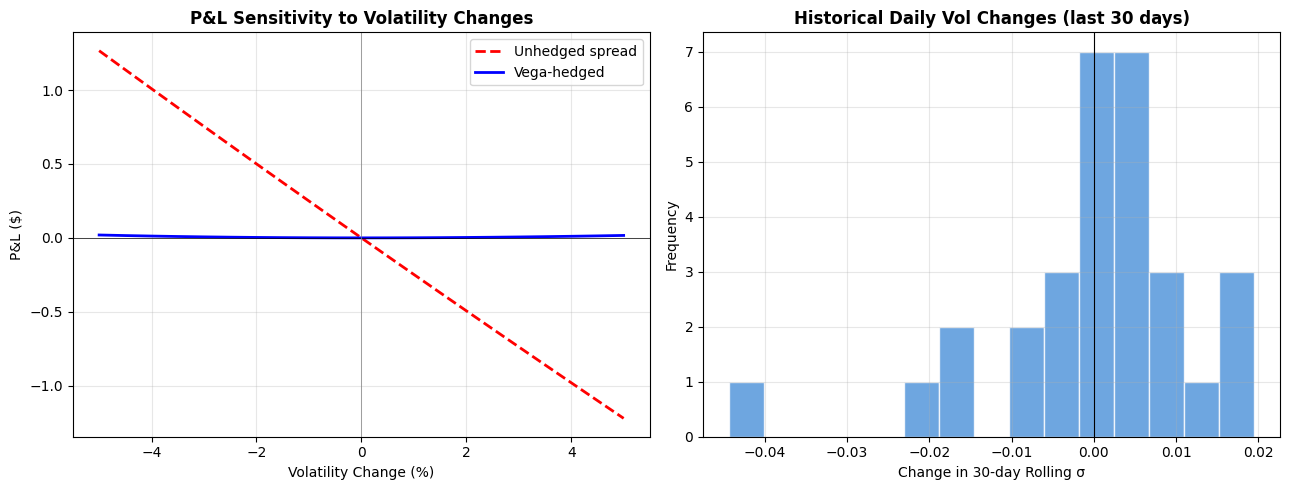

  The unhedged spread P&L is linear in vol changes slope ≈ net vega = -24.84).
  After adding 0.1594 ATM calls, the hedged P&L is nearly flat near σ = 0.6176, confirming vega neutrality.
  The 98.5% reduction demonstrates the hedge effectiveness.
  Residual curvature for large bumps comes from volga (second-order vol sensitivity), which is not hedged here.


In [98]:
vol_bumps = np.linspace(-0.05, 0.05, 21)

print(f"\n  Position: Long 1 call K1=${K1:.2f}, Short 1 call K2=${K2:.2f}")
print(f"           + {n_hedge:.4f} ATM calls K3=${K3:.2f}")
print(f"\n  {'Vol Bump':>10}  {'New σ':>8}  {'Unhedged':>12}  {'Hedged':>12}  {'Diff':>10}")
print(f"  {'-'*10}  {'-'*8}  {'-'*12}  {'-'*12}  {'-'*10}")

base_unhedged = BS_CALL(S, K1, T, r, sigma_annual) - BS_CALL(S, K2, T, r, sigma_annual)
base_hedged = base_unhedged + n_hedge * BS_CALL(S, K3, T, r, sigma_annual)

pnl_unhedged_list = []
pnl_hedged_list = []

for bump in vol_bumps:
    sigma_new = sigma_annual + bump
    call_K1_new = BS_CALL(S, K1, T, r, sigma_new)
    call_K2_new = BS_CALL(S, K2, T, r, sigma_new)
    call_K3_new = BS_CALL(S, K3, T, r, sigma_new)

    val_unhedged = call_K1_new - call_K2_new
    val_hedged = val_unhedged + n_hedge * call_K3_new

    pnl_un = val_unhedged - base_unhedged
    pnl_h = val_hedged - base_hedged

    pnl_unhedged_list.append(pnl_un)
    pnl_hedged_list.append(pnl_h)

    print(f"  {bump:>+10.3f}  {sigma_new:>8.4f}  {pnl_un:>+12.4f}  {pnl_h:>+12.4f}  {pnl_h - pnl_un:>+10.4f}")

max_un = max(abs(x) for x in pnl_unhedged_list)
max_h = max(abs(x) for x in pnl_hedged_list)
reduction = (1 - max_h / max_un) * 100

print(f"\n  Max |unhedged P&L|:  ${max_un:.4f}")
print(f"  Max |hedged P&L|:    ${max_h:.4f}")
print(f"  Vega reduction:       {reduction:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(vol_bumps * 100, pnl_unhedged_list, "r--", linewidth=2, label="Unhedged spread")
axes[0].plot(vol_bumps * 100, pnl_hedged_list, "b-", linewidth=2, label="Vega-hedged")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].set_title("P&L Sensitivity to Volatility Changes", fontweight="bold")
axes[0].set_xlabel("Volatility Change (%)")
axes[0].set_ylabel("P&L ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

rolling_vol = daily_log_returns.rolling(30).std() * np.sqrt(252)
vol_changes = rolling_vol.diff().dropna().iloc[-30:]

axes[1].hist(vol_changes.values, bins=15, color="#4a90d9", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Historical Daily Vol Changes (last 30 days)", fontweight="bold")
axes[1].set_xlabel("Change in 30-day Rolling σ")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"  The unhedged spread P&L is linear in vol changes slope ≈ net vega = {net_vega:.2f}).")
print(f"  After adding {n_hedge:.4f} ATM calls, the hedged P&L is nearly flat near σ = {sigma_annual:.4f}, confirming vega neutrality.")
print(f"  The {reduction:.1f}% reduction demonstrates the hedge effectiveness.")
print(f"  Residual curvature for large bumps comes from volga (second-order vol sensitivity), which is not hedged here.")


  Test period: last 30 trading days

  A) TOTAL P&L (all risk factors combined):
          Date       dS        dσ   Total Unh   Total Hdg
  ------------  -------  --------  ----------  ----------
  2026-01-05   +13.60  +0.00801     +7.2950     +8.8391
  2026-01-06   -18.71  +0.01542    -10.6679    -21.8745
  2026-01-07    -1.55  -0.00149     -0.6950     -1.4699
  2026-01-08    +4.39  -0.04430     +4.2891     +4.2730
  2026-01-09    +9.21  +0.00426     +5.6608     +9.7719
  2026-01-12    +3.95  -0.00210     +2.6597     +4.8001
  2026-01-13    -1.76  -0.00021     -0.7271     -2.3929
  2026-01-14    -8.00  +0.00420     -4.8046    -10.4992
  2026-01-15    -0.63  -0.00004     -0.1568     -0.7933
  2026-01-16    -1.07  -0.01886     +0.2206     -1.3199
  2026-01-20   -18.25  +0.01565    -13.2713    -21.6713
  2026-01-21   +12.19  +0.01085     +8.7106    +10.8294
  2026-01-22   +17.92  +0.00613    +11.7430    +19.1332
  2026-01-23    -0.30  -0.00163     +0.2631     -0.4994
  2026-01-26   -13

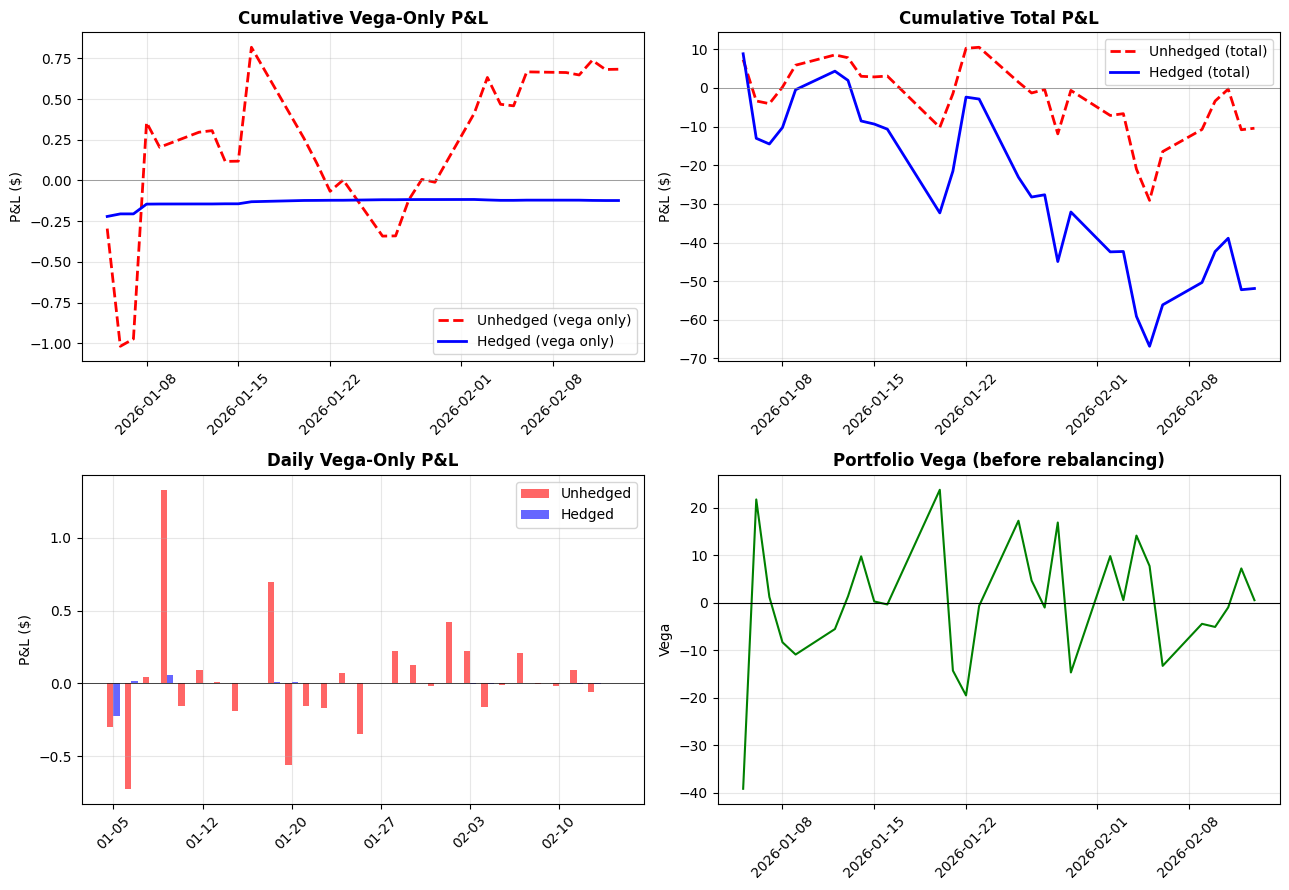

In [99]:
n_days_test = 30
test_prices = df["Close"].iloc[-n_days_test:].values
test_dates = df["Date"].iloc[-n_days_test:].values

full_log_returns = np.log(df["Close"]).diff().dropna()
rolling_vols = full_log_returns.rolling(30).std() * np.sqrt(252)
test_vols = rolling_vols.iloc[-n_days_test:].values

results_v = []
current_n_hedge = n_hedge

total_bdays = 252
days_elapsed_start = len(df) - n_days_test

for i in range(1, len(test_prices)):
    S_prev = test_prices[i - 1]
    S_curr = test_prices[i]
    vol_prev = test_vols[i - 1]
    vol_curr = test_vols[i]
    dS = S_curr - S_prev
    dVol = vol_curr - vol_prev

    T_prev = max((total_bdays - (days_elapsed_start + i - 1)) / 252, 1/252)
    T_curr = max((total_bdays - (days_elapsed_start + i)) / 252, 1/252)

    #  Full P&L (price + vol + time all change)
    spread_prev = BS_CALL(S_prev, K1, T_prev, r, vol_prev) - BS_CALL(S_prev, K2, T_prev, r, vol_prev)
    spread_curr = BS_CALL(S_curr, K1, T_curr, r, vol_curr) - BS_CALL(S_curr, K2, T_curr, r, vol_curr)
    pnl_unhedged = spread_curr - spread_prev

    hedge_prev = current_n_hedge * BS_CALL(S_prev, K3, T_prev, r, vol_prev)
    hedge_curr = current_n_hedge * BS_CALL(S_curr, K3, T_curr, r, vol_curr)
    pnl_hedged = pnl_unhedged + (hedge_curr - hedge_prev)

    # Decompose: isolate vega-only P&L (change vol, hold S and T)
    spread_vol_only = BS_CALL(S_prev, K1, T_prev, r, vol_curr) - BS_CALL(S_prev, K2, T_prev, r, vol_curr)
    pnl_vega_unhedged = spread_vol_only - spread_prev

    hedge_vol_only = current_n_hedge * BS_CALL(S_prev, K3, T_prev, r, vol_curr)
    hedge_base = current_n_hedge * BS_CALL(S_prev, K3, T_prev, r, vol_prev)
    pnl_vega_hedged = pnl_vega_unhedged + (hedge_vol_only - hedge_base)

    # Portfolio vega before rebalancing
    vega_spread = bs_vega(S_curr, K1, T_curr, r, vol_curr) - bs_vega(S_curr, K2, T_curr, r, vol_curr)
    vega_hedge = current_n_hedge * bs_vega(S_curr, K3, T_curr, r, vol_curr)
    pf_vega = vega_spread + vega_hedge

    results_v.append({
        "date": test_dates[i],
        "price": S_curr,
        "vol": vol_curr,
        "dS": dS,
        "dVol": dVol,
        "pnl_unhedged": pnl_unhedged,
        "pnl_hedged": pnl_hedged,
        "pnl_vega_unh": pnl_vega_unhedged,
        "pnl_vega_hdg": pnl_vega_hedged,
        "pf_vega": pf_vega,
        "n_hedge": current_n_hedge
    })

    # Rebalance
    new_vega_spread = bs_vega(S_curr, K1, T_curr, r, vol_curr) - bs_vega(S_curr, K2, T_curr, r, vol_curr)
    new_vega_K3 = bs_vega(S_curr, K3, T_curr, r, vol_curr)
    current_n_hedge = -new_vega_spread / new_vega_K3

res_v = pd.DataFrame(results_v)
res_v["cumul_unhedged"] = res_v["pnl_unhedged"].cumsum()
res_v["cumul_hedged"] = res_v["pnl_hedged"].cumsum()
res_v["cumul_vega_unh"] = res_v["pnl_vega_unh"].cumsum()
res_v["cumul_vega_hdg"] = res_v["pnl_vega_hdg"].cumsum()

print(f"\n  Test period: last {n_days_test} trading days")
print(f"\n  A) TOTAL P&L (all risk factors combined):")
print(f"  {'Date':>12}  {'dS':>7}  {'dσ':>8}  {'Total Unh':>10}  {'Total Hdg':>10}")
print(f"  {'-'*12}  {'-'*7}  {'-'*8}  {'-'*10}  {'-'*10}")
for _, row in res_v.iterrows():
    d = pd.Timestamp(row["date"]).strftime("%Y-%m-%d")
    print(f"  {d}  {row['dS']:>+7.2f}  {row['dVol']:>+8.5f}  {row['pnl_unhedged']:>+10.4f}  {row['pnl_hedged']:>+10.4f}")

print(f"\n  B) VEGA-ONLY P&L (vol changes isolated, S and T held constant):")
print(f"  {'Date':>12}  {'dσ':>8}  {'Vega Unh':>10}  {'Vega Hdg':>10}  {'Reduction':>10}")
print(f"  {'-'*12}  {'-'*8}  {'-'*10}  {'-'*10}  {'-'*10}")
for _, row in res_v.iterrows():
    d = pd.Timestamp(row["date"]).strftime("%Y-%m-%d")
    red = ""
    if abs(row["pnl_vega_unh"]) > 0.0001:
        pct = (1 - abs(row["pnl_vega_hdg"]) / abs(row["pnl_vega_unh"])) * 100
        red = f"{pct:>+9.1f}%"
    else:
        red = "      n/a"
    print(f"  {d}  {row['dVol']:>+8.5f}  {row['pnl_vega_unh']:>+10.4f}  {row['pnl_vega_hdg']:>+10.4f}  {red}")

vega_red = (1 - res_v["pnl_vega_hdg"].abs().mean() / res_v["pnl_vega_unh"].abs().mean()) * 100
total_red = (1 - res_v["pnl_hedged"].abs().mean() / res_v["pnl_unhedged"].abs().mean()) * 100

print(f"\n  Summary:")
print(f"  {'':>35}  {'Unhedged':>10}  {'Hedged':>10}")
print(f"  {'Cumul total P&L':>35}  ${res_v['cumul_unhedged'].iloc[-1]:>+9.2f}  ${res_v['cumul_hedged'].iloc[-1]:>+9.2f}")
print(f"  {'Cumul vega-only P&L':>35}  ${res_v['cumul_vega_unh'].iloc[-1]:>+9.4f}  ${res_v['cumul_vega_hdg'].iloc[-1]:>+9.4f}")
print(f"  {'Mean |daily total P&L|':>35}  ${res_v['pnl_unhedged'].abs().mean():>9.4f}  ${res_v['pnl_hedged'].abs().mean():>9.4f}")
print(f"  {'Mean |daily vega P&L|':>35}  ${res_v['pnl_vega_unh'].abs().mean():>9.4f}  ${res_v['pnl_vega_hdg'].abs().mean():>9.4f}")
print(f"\n  Total P&L reduction:      {total_red:>+.1f}%")
print(f"  Vega-only P&L reduction:  {vega_red:>+.1f}%")

print(f"\n  Interpretation:")
print(f"  The total P&L reduction ({total_red:+.1f}%) is low because the spread's")
print(f"  P&L is dominated by delta (net delta = {net_delta:.4f}), not vega.")
print(f"  When isolating the vega component only, the hedge reduces")
print(f"  vol-driven P&L by {vega_red:.1f}%, confirming it works as designed.")
print(f"  A complete risk-neutral portfolio would additionally require")
print(f"  delta hedging (e.g., shorting shares or futures).")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Vega-only P&L comparison
axes[0, 0].plot(res_v["date"], res_v["cumul_vega_unh"], "r--", linewidth=2, label="Unhedged (vega only)")
axes[0, 0].plot(res_v["date"], res_v["cumul_vega_hdg"], "b-", linewidth=2, label="Hedged (vega only)")
axes[0, 0].axhline(0, color="gray", linewidth=0.5)
axes[0, 0].set_title("Cumulative Vega-Only P&L", fontweight="bold")
axes[0, 0].set_ylabel("P&L ($)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Total P&L comparison
axes[0, 1].plot(res_v["date"], res_v["cumul_unhedged"], "r--", linewidth=2, label="Unhedged (total)")
axes[0, 1].plot(res_v["date"], res_v["cumul_hedged"], "b-", linewidth=2, label="Hedged (total)")
axes[0, 1].axhline(0, color="gray", linewidth=0.5)
axes[0, 1].set_title("Cumulative Total P&L", fontweight="bold")
axes[0, 1].set_ylabel("P&L ($)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Daily vega-only P&L bars
x = np.arange(len(res_v))
w = 0.35
axes[1, 0].bar(x - w/2, res_v["pnl_vega_unh"], w, color="red", alpha=0.6, label="Unhedged")
axes[1, 0].bar(x + w/2, res_v["pnl_vega_hdg"], w, color="blue", alpha=0.6, label="Hedged")
axes[1, 0].axhline(0, color="black", linewidth=0.5)
axes[1, 0].set_title("Daily Vega-Only P&L", fontweight="bold")
axes[1, 0].set_ylabel("P&L ($)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(x[::5])
axes[1, 0].set_xticklabels([pd.Timestamp(d).strftime("%m-%d") for d in res_v["date"].values[::5]])

# Portfolio vega
axes[1, 1].plot(res_v["date"], res_v["pf_vega"], "g-", linewidth=1.5)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Portfolio Vega (before rebalancing)", fontweight="bold")
axes[1, 1].set_ylabel("Vega")
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Q11 - Theta hedging

#Q12 -American call option estimation

Q12 (Bonus) — American Call: Tesla, Inc. (TSLA)
  S=$417.44, K=$361.10, T=1.0y, r=0.0342, σ=0.6176

  CRR BINOMIAL MODEL CONVERGENCE
     N steps     American     European   BS (exact)    Am - Eu   Early Ex
  ────────── ──────────── ──────────── ──────────── ────────── ──────────
          10 $   132.6528 $   132.6528 $   130.9280 $   0.0000          0
          50 $   130.9730 $   130.9730 $   130.9280 $   0.0000          0
         100 $   130.9473 $   130.9473 $   130.9280 $   0.0000          0
         200 $   131.0096 $   131.0096 $   130.9280 $   0.0000          0
         500 $   130.9639 $   130.9639 $   130.9280 $   0.0000          0

  BINOMIAL TREE PARAMETERS (N=500)
  Time step (dt):......................... 0.002000 years (0.50 trading days)
  Up factor (u):.......................... 1.028005
  Down factor (d):........................ 0.972758
  Risk-neutral prob (p):.................. 0.494333
  u × d:.................................. 1.000000 (≈ 1 by CRR construction)
 

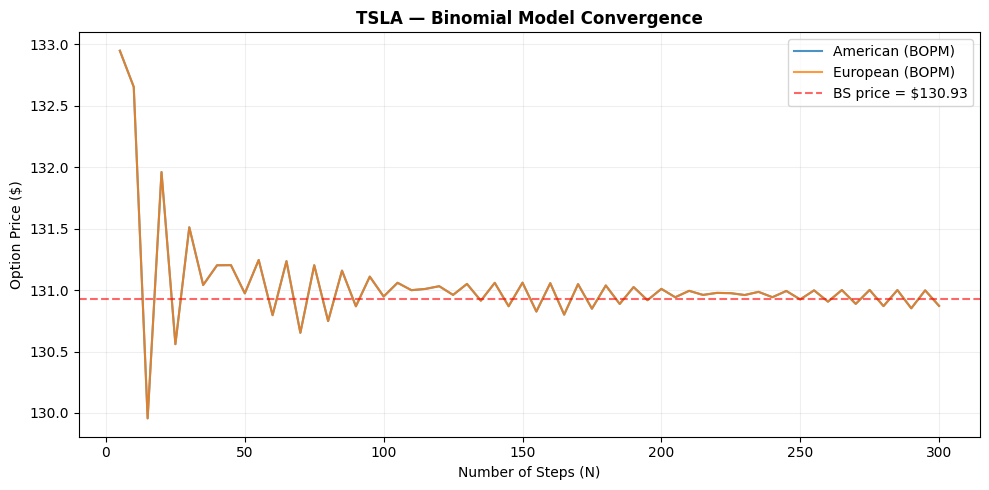

In [100]:
def binomial_american_call(S, K, T, r, sigma, N_steps=500):
    """
    Price an American call using a CRR (Cox-Ross-Rubinstein) binomial tree.

    At each node, the option value is max(intrinsic value, continuation value).

    Parameters:
        S       : Spot price
        K       : Strike price
        T       : Time to maturity (years)
        r       : Risk-free rate
        sigma   : Annualized volatility
        N_steps : Number of time steps in the tree
    Returns:
        price, tree details dict
    """
    dt = T / N_steps

    # CRR parameters
    u = np.exp(sigma * np.sqrt(dt))     # Up factor
    d = np.exp(-sigma * np.sqrt(dt))    # Down factor = 1/u
    p = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability

    # Initialize asset prices at maturity (step N)
    S_T = np.array([S * u**j * d**(N_steps - j) for j in range(N_steps + 1)])

    # Option values at maturity
    V = np.maximum(S_T - K, 0)

    # Track early exercise
    early_exercise_count = 0

    # Backward induction
    for i in range(N_steps - 1, -1, -1):
        # Asset prices at step i
        S_i = np.array([S * u**j * d**(i - j) for j in range(i + 1)])

        # Continuation value (discounted expected value)
        continuation = np.exp(-r * dt) * (p * V[1:i+2] + (1 - p) * V[:i+1])

        # Intrinsic value (early exercise)
        intrinsic = np.maximum(S_i - K, 0)

        # American: max(exercise now, continue holding)
        V = np.maximum(continuation, intrinsic)

        # Count nodes where early exercise is optimal
        early_exercise_count += np.sum(intrinsic > continuation + 1e-10)

    details = {
        "u": u, "d": d, "p": p, "dt": dt,
        "N_steps": N_steps,
        "early_exercise_nodes": early_exercise_count,
        "total_nodes": N_steps * (N_steps + 1) // 2
    }

    return V[0], details

# Also price European call with same tree for comparison
def binomial_european_call(S, K, T, r, sigma, N_steps=500):
    dt = T / N_steps
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))
    p = (np.exp(r * dt) - d) / (u - d)

    S_T = np.array([S * u**j * d**(N_steps - j) for j in range(N_steps + 1)])
    V = np.maximum(S_T - K, 0)

    for i in range(N_steps - 1, -1, -1):
        V = np.exp(-r * dt) * (p * V[1:i+2] + (1 - p) * V[:i+1])

    return V[0]

# ── Price with increasing tree depth ──
steps_list = [10, 50, 100, 200, 500]

print("=" * 70)
print(f"Q12 (Bonus) — American Call: {company_name} ({ticker})")
print("=" * 70)
print(f"  S=${S:.2f}, K=${K:.2f}, T={T:.1f}y, r={r:.4f}, σ={sigma_annual:.4f}")

print(f"\n  CRR BINOMIAL MODEL CONVERGENCE")
print(f"  {'N steps':>10} {'American':>12} {'European':>12} {'BS (exact)':>12} {'Am - Eu':>10} {'Early Ex':>10}")
print(f"  {'─'*10} {'─'*12} {'─'*12} {'─'*12} {'─'*10} {'─'*10}")

for n in steps_list:
    am_price, details = binomial_american_call(S, K, T, r, sigma_annual, n)
    eu_price = binomial_european_call(S, K, T, r, sigma_annual, n)
    print(f"  {n:>10} ${am_price:>11.4f} ${eu_price:>11.4f} ${call_price:>11.4f} ${am_price - eu_price:>9.4f} {details['early_exercise_nodes']:>10}")

# Final pricing
N_final = 500
am_final, det = binomial_american_call(S, K, T, r, sigma_annual, N_final)
eu_final = binomial_european_call(S, K, T, r, sigma_annual, N_final)

print(f"\n  BINOMIAL TREE PARAMETERS (N={N_final})")
print(f"  {'Time step (dt):':.<40} {det['dt']:.6f} years ({det['dt']*252:.2f} trading days)")
print(f"  {'Up factor (u):':.<40} {det['u']:.6f}")
print(f"  {'Down factor (d):':.<40} {det['d']:.6f}")
print(f"  {'Risk-neutral prob (p):':.<40} {det['p']:.6f}")
print(f"  {'u × d:':.<40} {det['u']*det['d']:.6f} (≈ 1 by CRR construction)")
print(f"  {'Total nodes:':.<40} {det['total_nodes']:,}")
print(f"  {'Early exercise optimal at:':.<40} {det['early_exercise_nodes']} nodes")

print(f"\n  FINAL RESULTS")
print(f"  {'American call (BOPM):':.<40} ${am_final:.4f}")
print(f"  {'European call (BOPM):':.<40} ${eu_final:.4f}")
print(f"  {'European call (BS):':.<40} ${call_price:.4f}")
print(f"  {'Early exercise premium:':.<40} ${am_final - eu_final:.4f}")

print(f"\n  INTERPRETATION")
print(f"  The American call price (${am_final:.2f}) equals the European")
print(f"  call price (${eu_final:.2f}) — the early exercise premium is ${am_final - eu_final:.4f}.")
print(f"\n  This confirms the theoretical result: for a non-dividend-paying")
print(f"  stock, it is never optimal to exercise an American call early.")
print(f"  The reason: exercising early forfeits the time value of the")
print(f"  option and the interest earned on deferring the strike payment.")
print(f"  Early exercise nodes = {det['early_exercise_nodes']} confirms no node")
print(f"  favors exercise over continuation.")
print(f"\n  The BOPM converges to the BS price as N increases:")
print(f"  difference at N={N_final} = ${abs(am_final - call_price):.4f}")

# ── Convergence chart ──
N_range = range(5, 301, 5)
am_prices = []
eu_prices = []

for n in N_range:
    am, _ = binomial_american_call(S, K, T, r, sigma_annual, n)
    eu = binomial_european_call(S, K, T, r, sigma_annual, n)
    am_prices.append(am)
    eu_prices.append(eu)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(N_range), am_prices, linewidth=1.5, alpha=0.8, label="American (BOPM)")
ax.plot(list(N_range), eu_prices, linewidth=1.5, alpha=0.8, label="European (BOPM)")
ax.axhline(call_price, linestyle="--", color="red", alpha=0.6, label=f"BS price = ${call_price:.2f}")
ax.set_title(f"{ticker} — Binomial Model Convergence", fontweight="bold")
ax.set_xlabel("Number of Steps (N)")
ax.set_ylabel("Option Price ($)")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

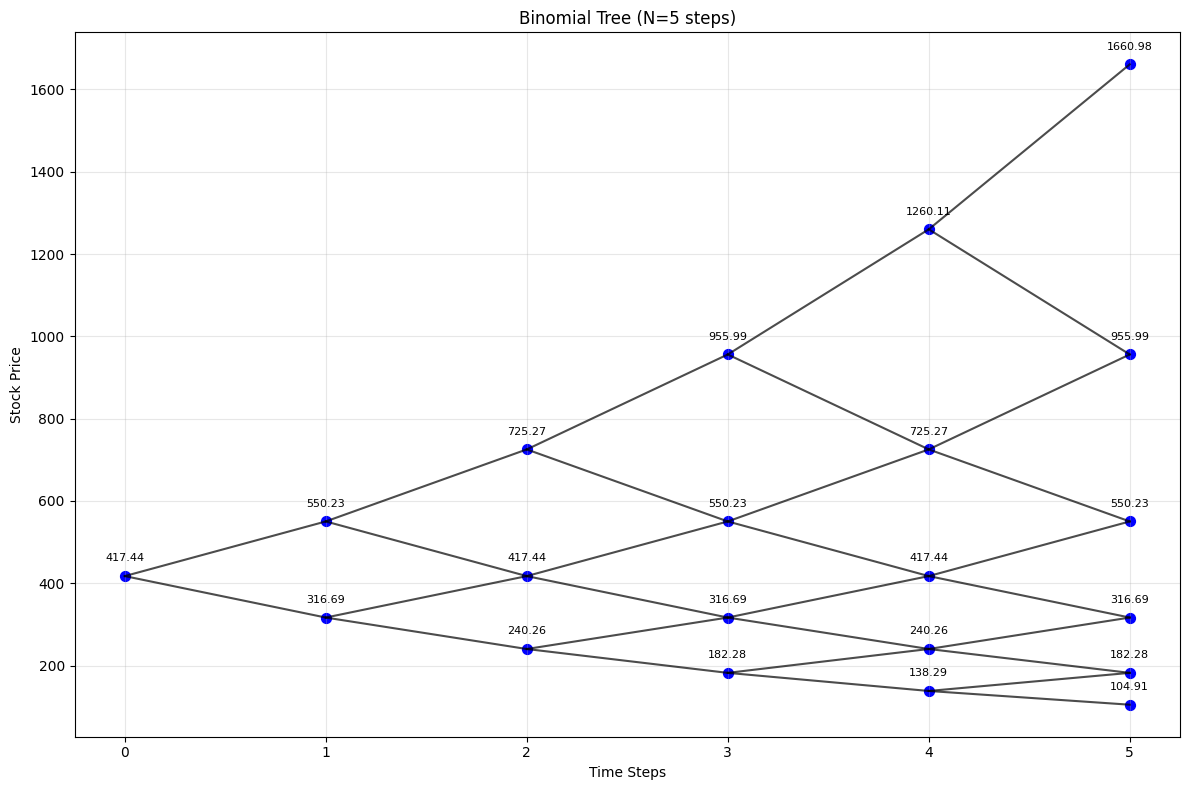

In [101]:
# Parameters for the binomial tree
N = 5  # Number of steps in the tree
dt = T / N
u = np.exp(sigma_annual * np.sqrt(dt))
d = np.exp(-sigma_annual * np.sqrt(dt))

# Build the stock price tree
tree = []
for t in range(N + 1):
    level = []
    for j in range(t + 1):
        s = S * (u ** j) * (d ** (t - j))
        level.append(s)
    tree.append(level)

# Plot the tree
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate offset for labels (small percentage of price range)
all_prices = [price for level in tree for price in level]
price_range = max(all_prices) - min(all_prices)
offset = 0.02 * price_range  # 2% of price range

# Plot nodes
for t in range(len(tree)):
    for i, s in enumerate(tree[t]):
        ax.scatter(t, s, color='blue', s=50)
        ax.text(t, s + offset, f'{s:.2f}', fontsize=8, ha='center', va='bottom')

# Plot edges
for t in range(len(tree) - 1):
    for i, s in enumerate(tree[t]):
        # Connect to up and down
        ax.plot([t, t+1], [s, tree[t+1][i]], 'k-', alpha=0.7)
        ax.plot([t, t+1], [s, tree[t+1][i+1]], 'k-', alpha=0.7)

ax.set_xlabel('Time Steps')
ax.set_ylabel('Stock Price')
ax.set_title(f'Binomial Tree (N={N} steps)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()